# LiDAR-to-Spatial-Audio Navigation Aid — System Prototype

This notebook presents the implemented components of the navigation aid prototype for visually impaired users.

Sections covered:
- Loading and preloading recorded depth frames from iPhone LiDAR (.npy format)
- Loading HRTF impulse responses from a SOFA file and building a KDTree for direction lookup
- Visualising depth frames alongside RGB footage with false-colour mapping
- Generating spatialized audio pings using pink noise, bandpass filtering, and HRTF convolution
- Mapping depth image pixels to azimuth/elevation angles using camera intrinsics
- Extracting horizontal scan profiles with elevation-based floor filtering
- Building time-sequenced stereo sweeps from scan point arrays
- Synchronised sweep playback with inline depth visualisation
- Frame-by-frame depth video playback with sweep overlay (sequential prototype)
- Semi real-time simulation using concurrent video and audio threads with crossfade blending
- Proposed next steps: LiDAR-based dynamic hazard tracking and RGB peripheral detection


The notebook is structured to be run top-to-bottom; each section builds on the outputs of the previous one.

## 1. Dependencies

The following libraries are used for numerical processing, visualization, HRTF handling, and audio playback.

In [2]:
# Numerical / signal processing
import numpy as np
from scipy.spatial import KDTree
from scipy.signal import fftconvolve, butter, sosfilt
from scipy import ndimage
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False

# Audio
import sounddevice as sd
import sofar as sf

# Image / visualisation
import cv2
import matplotlib.pyplot as plt
cv2.ocl.setUseOpenCL(True)

# Standard library
import os, json, time, threading


## 2. Input files

This section defines the paths for:
- the recorded depth frames
- the metadata file from the recording
- the SOFA file containing HRTF impulse responses

In [3]:
# Directory of stored depth folder (You must change these)
DEPTH_DIR = r"D:\DepthExport-2026-05-04T13-01-55.597Z_extracted\depth"
# RGB_DIR = r"D:\GradProj\output1\rgb"
META = r"D:\DepthExport-2026-05-04T13-01-55.597Z_extracted\metadata.json"
SOFA = sf.read_sofa("D:\GradProj\H10_HRIR_SOFA\H10_48K_24bit_256tap_FIR_SOFA.sofa")

SOFA file contained custom entries
----------------------------------
GLOBAL_NCProperties


## 3. Load recorded depth frames

The depth recording consists of `.npy` files, one per frame.
The function below:
- finds all frame files
- reads the first frame to determine image dimensions
- preallocates a NumPy array for efficiency
- loads all depth frames into memory

Preloading depth improves playback and analysis speed during later steps.

*NOTE:* We don't preload the RGB frames becuase it will make your RAM cry

In [4]:
# Function to load depth, just run this block
def load_depth(depth_dir):
    
    files = sorted([f for f in os.listdir(depth_dir) if f.endswith('.npy')])
    n_frames = len(files)

    sample = np.load(os.path.join(depth_dir, files[0]))
    h, w = sample.shape

    depths = np.zeros((n_frames, h, w), dtype=np.float32)

    for i, fname in enumerate(files):
        depths[i] = np.load(os.path.join(depth_dir, fname))
        if i % 200 == 0:
            print(f"  {i}/{n_frames}")
            
    return depths, n_frames

In [5]:
# Loading depths
depths, frames = load_depth(DEPTH_DIR)

  0/978
  200/978
  400/978
  600/978
  800/978


### Verify loaded data

This section prints basic information about the loaded depth recording as well as a small visualization to confirm that the frames were read correctly.

In [6]:
print("Depth array shape:", depths.shape)
print("Number of frames:", frames)
print("First frame dtype:", depths[0].dtype)
print("Min depth in first frame:", np.nanmin(depths[0]))
print("Max depth in first frame:", np.nanmax(depths[0]))

Depth array shape: (978, 192, 256)
Number of frames: 978
First frame dtype: float32
Min depth in first frame: 0.0
Max depth in first frame: 7.8671875


### Visualization Function

In [7]:
def depth_to_colormap(depth, colormap=cv2.COLORMAP_VIRIDIS, size=None):
    d = depth.copy()
    finite = np.isfinite(d)

    if not np.any(finite):
        disp = np.zeros_like(d, dtype=np.uint8)
    else:
        mn = np.nanmin(d[finite])
        mx = np.nanmax(d[finite])

        if np.isclose(mn, mx):
            disp = np.zeros_like(d, dtype=np.uint8)
        else:
            disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)

    if size is not None:
        disp = cv2.resize(disp, size)

    colored = cv2.applyColorMap(disp, colormap)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

    return colored

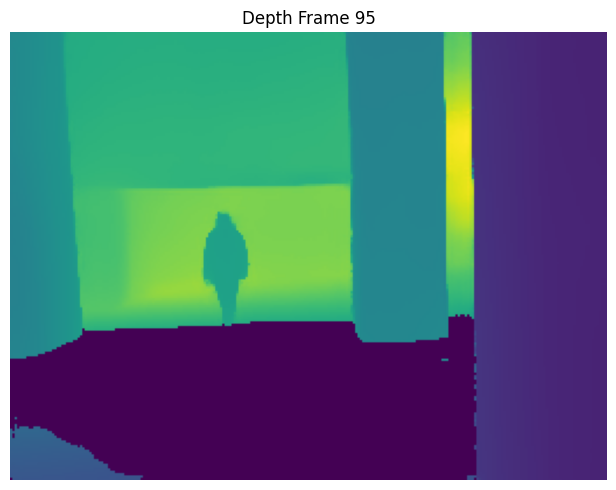

In [8]:
i = 95
# Pick frame

# Depth frame
d = depths[i]
d_color = depth_to_colormap(d)

# Plot
plt.figure(figsize=(12, 5))
plt.imshow(d_color)
plt.title(f"Depth Frame {i}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Verify HRTF (SOFA) data and spatial audio

This section demonstrates how spatial audio is generated using HRTF data.

The SOFA file contains Head-Related Impulse Responses (HRIRs), which encode how sound arriving from a specific direction is filtered by the human head and ears.

By convolving a sound signal with these impulse responses:
- the sound can be perceived as coming from a specific direction
- spatial awareness can be simulated using headphones

In this section:
- we inspect the SOFA dataset
- we select directions from it
- we generate spatialized "ping" sounds
- the user can test how direction changes the perceived sound location
  
**Note:** Headphones are required

In [9]:
print("SOFA Data_IR shape:", SOFA.Data_IR.shape)
print("Number of directions:", SOFA.Data_IR.shape[0])
print("Samples per IR:", SOFA.Data_IR.shape[2])


SOFA Data_IR shape: (2114, 2, 256)
Number of directions: 2114
Samples per IR: 256


The SOFA dataset stores:
- one impulse response per direction
- two channels per direction (left ear, right ear)

Shape meaning:
<div style="float: left; width: 100%;">

| Axis | Size | Meaning |
| :--- | :--- | :--- |
| M | number of directions | one IR per direction |
| 2 | channels | left ear / right ear |
| N | samples per IR | impulse response length |

</div>


### KDTree for HRTF Direction Lookup

The SOFA dataset contains impulse responses measured at many discrete directions,
each defined by:
- `azimuth (horizontal angle)`
- `elevation (vertical angle)`

However, when generating spatial audio, we may request a direction that does not exactly exist in the dataset.

To handle this, we use a KDTree:
- it stores all available directions as points in a 2D space (azimuth, elevation)
- given a requested direction, it efficiently finds the *closest available direction* using Euclidean distance in the (azimuth, elevation) plane

This allows us to approximate any direction using the nearest measured HRTF.

#### Effect of weighting

Weights allow control over how "important" each dimension is when selecting the nearest HRTF.

- Increasing azimuth weight → improves left/right accuracy
- Decreasing elevation weight → reduces sensitivity to vertical differences

This is useful because:
- human perception is generally more sensitive to horizontal localization
- the system primarily operates in a horizontal scanning mode

Example:
w = [1.0, 0.3] prioritizes azimuth over elevation

In [10]:
azimuths = SOFA.SourcePosition[:, 0]
elevations = SOFA.SourcePosition[:, 1]
w = [1.0, 1.0] # You can change and play around with these weights
points = np.column_stack([w[0] * azimuths, w[1] * elevations])
# Create the KD Tree
tree = KDTree(points)

In [11]:
print("Azimuth range:")
print(f"Min:{np.min(azimuths)}°")
print(f"Max:{np.max(azimuths)}°")

print("\nElevation range:")
print(f"Min: {np.min(elevations)}°")
print(f"Max: {np.max(elevations)}°")

print("\nUnique azimuth samples (first 10):")
print(np.unique(azimuths)[:10])

print("\nUnique elevation samples:")
print(np.unique(elevations))

Azimuth range:
Min:0.0°
Max:355.0°

Elevation range:
Min: -90.0°
Max: 90.0°

Unique azimuth samples (first 10):
[ 0.   5.  10.  12.8 13.3 15.  17.1 18.  18.4 19. ]

Unique elevation samples:
[-90.  -81.  -75.  -64.8 -60.  -54.  -45.  -35.3 -30.  -25.  -17.5 -15.
   0.   15.   17.5  25.   30.   35.3  45.   54.   60.   64.8  75.   90. ]


In [12]:
# Test direction (you can change this)
test_az = 30.0
test_el = 10.0

# Query KDTree
dist, idx = tree.query([w[0] * test_az, w[1] * test_el])

# Retrieved direction from SOFA
nearest_az = azimuths[idx]
nearest_el = elevations[idx]

print("\nRequested direction:")
print(f"  Azimuth: {test_az}°, Elevation: {test_el}°")

print("\nNearest HRTF direction:")
print(f"  Azimuth: {nearest_az}°, Elevation: {nearest_el}°")

print("\nDistance (in weighted space):", dist)


Requested direction:
  Azimuth: 30.0°, Elevation: 10.0°

Nearest HRTF direction:
  Azimuth: 30.0°, Elevation: 15.0°

Distance (in weighted space): 5.0


### Generate a spatialized ping 

The function below generates a stereo ping that simulates a sound coming from a specified spatial direction. 

**Inputs:** 
- `azimuth` 
- `elevation` 
- `distance` 

**Processing steps:**
1. **Convert the azimuth** into the coordinate convention used by the SOFA dataset. (0-355)
2. **Find the nearest available HRTF direction** using the KDTree.
3. **Generate a short ping signal.**
4. **Filter and smooth** the ping.
5. **Convolve the ping** with the left and right HRIRs.
6. **Scale the output based on distance**  
   The gain is calculated using the following formula:
   $$
   \begin{flalign}
   &\text{gain} = G_{min} + (G_{max} - G_{min}) \left(1 - \frac{d}{d_{max}}\right)^{amp}&& \\
   \end{flalign}
   $$  
   *You can tweak this formula to change the sensitivity as you like.*

The result is a stereo signal that can be played through headphones to perceive spatial direction. 

**NOTE:** Since the SADIE II datasets has azimuths in the range 0–355 and the iPhone FOV is in the range -35 to 35, we must map these values using modular arithmetic.


#### Pink noise generation

Instead of using white noise, this system uses *pink noise* to generate the base signal for spatial pings.

White noise has equal energy across all frequencies and can sound harsh and unnatural.
Pink noise, by contrast, has energy that decreases with frequency (∝ 1/√f), making it 
perceptually more balanced and better matched to human auditory sensitivity.

The function below generates pink noise by:
1. creating white noise
2. transforming it into the frequency domain
3. scaling frequencies to follow a 1/√f distribution
4. transforming back to the time domain

In [13]:
def pink_noise(n):
    
    # white noise
    x = np.random.randn(n)

    # go to frequency domain with fast fourier transform
    X = np.fft.rfft(x)
    
    freqs = np.fft.rfftfreq(n)
    freqs[0] = 1.0  # avoid division by zero

    # apply 1/sqrt(f) scaling
    X /= np.sqrt(freqs)

    # back to time domain (inverse fourier transform)
    y = np.fft.irfft(X, n)
    y = y / (np.max(np.abs(y)) + 1e-8) 
    
    return y.astype(np.float32)

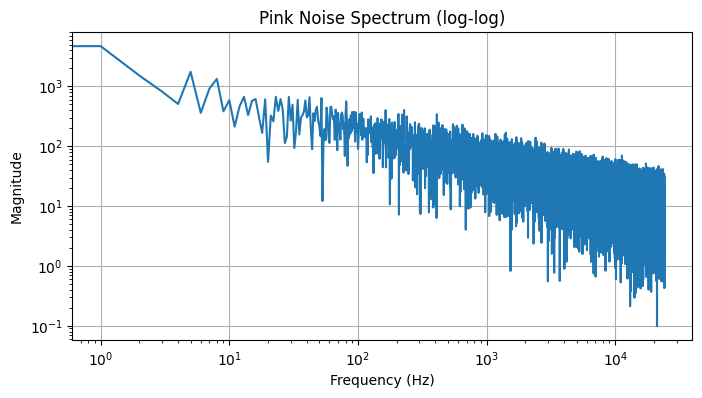

In [14]:
# visualize frequency content
n = 48000
y = pink_noise(n)

Y = np.abs(np.fft.rfft(y))
freqs = np.fft.rfftfreq(n, 1/48000)

plt.figure(figsize=(8,4))
plt.plot(freqs, Y)
plt.xscale("log")
plt.yscale("log")
plt.title("Pink Noise Spectrum (log-log)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

The downward slope confirms that higher frequencies have lower energy, characteristic of pink noise.

In [15]:
def find_nearest_hrtf_index(azimuth, elevation, tree):
    az_sadie = (-azimuth) % 360
    _, idx = tree.query([az_sadie, elevation])
    return idx

In [16]:
def make_spatial_ping(azimuth, elevation, distance, sofa, tree,
                      sample_rate=48000, max_range=2.0, dur=0.5,
                      bandpass=[1200, 6000], amp=1):

    # find nearest HRIR
    az_sadie = (-azimuth) % 360 # This is needed to convert from (-35,35) -> (0, 355)
    idx = find_nearest_hrtf_index(azimuth, elevation, tree)

    # HRIR
    hrir_left = sofa.Data_IR[idx, 0, :]   # left channel
    hrir_right = sofa.Data_IR[idx, 1, :]  # right channel
    
    # create ping
    n = max(1, int(dur * sample_rate))
    ping = pink_noise(n)

    # bandpass filter
    sos = butter(4, bandpass, btype="bandpass", fs=sample_rate, output="sos")
    ping = sosfilt(sos, ping).astype(np.float32)

    # hanning window for smoothing
    ping *= np.hanning(n).astype(np.float32)

    # Convolution
    left = fftconvolve(ping, hrir_left, mode="full").astype(np.float32)
    right = fftconvolve(ping, hrir_right, mode="full").astype(np.float32)

    # Distance-Gain calculation
    d = np.clip(distance, 0.0, max_range)
    min_gain, max_gain = 0.08, 1.0
    gain = min_gain + (max_gain - min_gain) * (1 - d / max_range) ** amp
    left *= gain
    right *= gain

    stereo = np.column_stack((left, right)).astype(np.float32)

    return stereo

#### Listening test

The following example generates a ping from a chosen direction and distance.

When played through headphones:
- negative azimuth values should be perceived from the left
- positive azimuth values should be perceived from the right
- larger distances should sound quieter than smaller distances

In [17]:
audio = make_spatial_ping(
    azimuth=+35,
    elevation=-25,
    distance=1,
    sofa=SOFA,
    tree=tree
)

sd.play(audio, 48000)
sd.wait()

#### Future user customization

A future version of the system should allow user-specific customization of the spatial audio parameters.

This is important because different users may perceive spatial cues differently depending on:
- ear shape
- head-related acoustic differences
- sensitivity to certain frequency ranges
- personal comfort with different ping durations or repetition rates

Possible customization options include:
- selecting between different HRTF datasets (KEMAR MIT, LISTEN, SADIE II, etc.)
- adjusting the ping frequency range
- changing ping duration
- changing loudness scaling with distance
- tuning the balance between directional clarity and listening comfort

This is a future development point and is not yet implemented in the current prototype.

## 5. Sweep-based sonification with HRTF

This section demonstrates how a 2D depth frame is converted into a sequence of spatial audio cues.

The approach is based on a left-to-right sweep:
- the image is scanned column by column
- each column represents a viewing direction
- the nearest obstacle in that column is selected
- that obstacle is converted into a spatialized audio ping

This creates a temporal sequence of sounds that represent the spatial structure of the scene.

### Mapping image pixels to viewing angles

Each pixel in the depth image corresponds to a specific viewing direction.

Using the camera intrinsic parameters obtained from metadata file:
- \( f_x, f_y \): focal lengths
- \( c_x, c_y \): optical center

we can convert pixel coordinates into angles.

For a pixel at column \(u\) and row \(v\):

$$
\begin{flalign}
&\text{azimuth}(u) = \tan^{-1}\left(\frac{u - c_x}{f_x}\right)&& \\
&\text{elevation}(v) = - \tan^{-1}\left(\frac{v - c_y}{f_y}\right)&&
\end{flalign}
$$


This gives:
- azimuth → horizontal direction (left/right)
- elevation → vertical direction (up/down)

These angles describe the direction of each pixel relative to the camera.

In [119]:
_METADATA_CACHE = {}

def load_metadata(f):
    if f not in _METADATA_CACHE:
        with open(f) as meta_file:
            _METADATA_CACHE[f] = json.load(meta_file)
    return _METADATA_CACHE[f]

def get_camera_data(meta):
    camera = meta["camera"]
    fx, fy, cx, cy = camera["intrinsics"]["fx"], camera["intrinsics"]["fy"], camera["intrinsics"]["cx"], camera["intrinsics"]["cy"]
    dw, dh = meta["depth"]["width"], meta["depth"]["height"]
    w, h = camera["width"], camera["height"]

    # Focal Points (Scaled)
    fx_d = fx * (dw / w)
    fy_d = fy * (dh / h)
    # Cam Center (Scaled)
    cx_d = cx * (dw / w)
    cy_d = cy * (dh / h)

    return fx_d, fy_d, cx_d, cy_d

def prepare_pose_cache(meta):
    poses = np.array([frame["pose"] for frame in meta["frames"]]).reshape(-1 , 4, 4)
    rotations = poses[:, :3, :3]
    translations = poses[:, :3, 3]
    timestamps = np.array([f["timestamp"] for f in meta["frames"]])
    return rotations, translations, timestamps

def get_pose(idx):
    # Poses are cached once because reading/parsing metadata JSON per frame costs several ms.
    return POSE_R[idx], POSE_T[idx], POSE_TS[idx]

def read_pixels(d, fx_d, fy_d, cx_d, cy_d):
    h, w = d.shape
    u = np.arange(w)
    v = np.arange(h)

    azimuths = np.arctan((u - cx_d) / fx_d)
    elevations = -np.arctan((v - cy_d) / fy_d) # Negated because video is filmed in landscape mode

    return np.rad2deg(azimuths), np.rad2deg(elevations)


In [19]:
meta = load_metadata(META);

# These are fixed for this recording session and do not change frame-to-frame.
FX, FY, CX, CY = get_camera_data(meta)
POSE_R, POSE_T, POSE_TS = prepare_pose_cache(meta)
AZI, ELV = read_pixels(depths[0], FX, FY, CX, CY)

print(f"Focal lengths : fx={FX:.2f}, fy={FY:.2f}")
print(f"Optical centre: cx={CX:.2f}, cy={CY:.2f}")
print(f"Min-Max AZI: min(AZI)={min(AZI):.2f}, max(AZI) = {max(AZI):.2f}")
print(f"Min-Max ELV: min(ELV)={min(ELV):.2f}, max(ELV) = {max(ELV):.2f}")


Focal lengths : fx=178.24, fy=178.24
Optical centre: cx=127.80, cy=97.26
Min-Max AZI: min(AZI)=-35.64, max(AZI) = 35.51
Min-Max ELV: min(ELV)=-27.74, max(ELV) = 28.62


### Scan strategy

To reduce the 2D depth frame into a manageable representation:

- a subset of image columns is selected
- for each column:
  - all depth values are examined
  - the nearest valid depth value is selected
  - the corresponding pixel location is identified

From this pixel:
- column index → azimuth
- row index → elevation
- depth value → distance

This produces a set of spatial samples across the field of view.

**NOTE:** A naive scan would select the nearest depth value in each column. However, this often causes the floor to dominate the result, since the ground plane is usually one of the closest visible surfaces. To reduce this effect, elevation-based filtering is used.

In [20]:
def extract_scan_points(d, azimuths=AZI, elevations=ELV, num_cols=32, max_range=6.0, min_elevation = -35, max_elevation = 35):

    _, w = d.shape
    scan_cols = np.linspace(0, w - 1, num_cols, dtype=int)
    cols = d[:, scan_cols]

    valid_elevation = (elevations >= min_elevation) & (elevations <= max_elevation)
    mask = np.isfinite(cols) & (cols > 0) & (cols <= max_range) & valid_elevation[:, None]
    valid_mask = np.any(mask, axis=0)

    masked_cols = np.argmin(np.where(mask, cols, np.inf), axis = 0)

    u = scan_cols[valid_mask]
    v = masked_cols[valid_mask]

    return azimuths[u], elevations[v], d[v, u].astype(float), u, v

#### Verification of extracted scan points

The following output shows a few extracted scan samples:
- azimuth (degrees)
- elevation (degrees)
- distance (meters)

This confirms that each scan position produces a valid spatial sample.

In [21]:
near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(depths[0], min_elevation = -15, max_elevation = 15)

for i in range(5):
    print(f"Sample {i}:")
    print(f"Azimuth:{near_az[i]}°")
    print(f"Elevation:{near_el[i]}°")
    print(f"Distance:{near_dist[i]} m")

Sample 0:
Azimuth:-35.64047895531388°
Elevation:14.850306821371857°
Distance:4.51171875 m
Sample 1:
Azimuth:-33.90566801814125°
Elevation:-14.993951099583859°
Distance:4.5390625 m
Sample 2:
Azimuth:-32.097277477328824°
Elevation:-14.993951099583859°
Distance:4.5234375 m
Sample 3:
Azimuth:-30.214360701893945°
Elevation:-14.993951099583859°
Distance:4.48828125 m
Sample 4:
Azimuth:-28.256534987252024°
Elevation:-14.993951099583859°
Distance:4.44921875 m


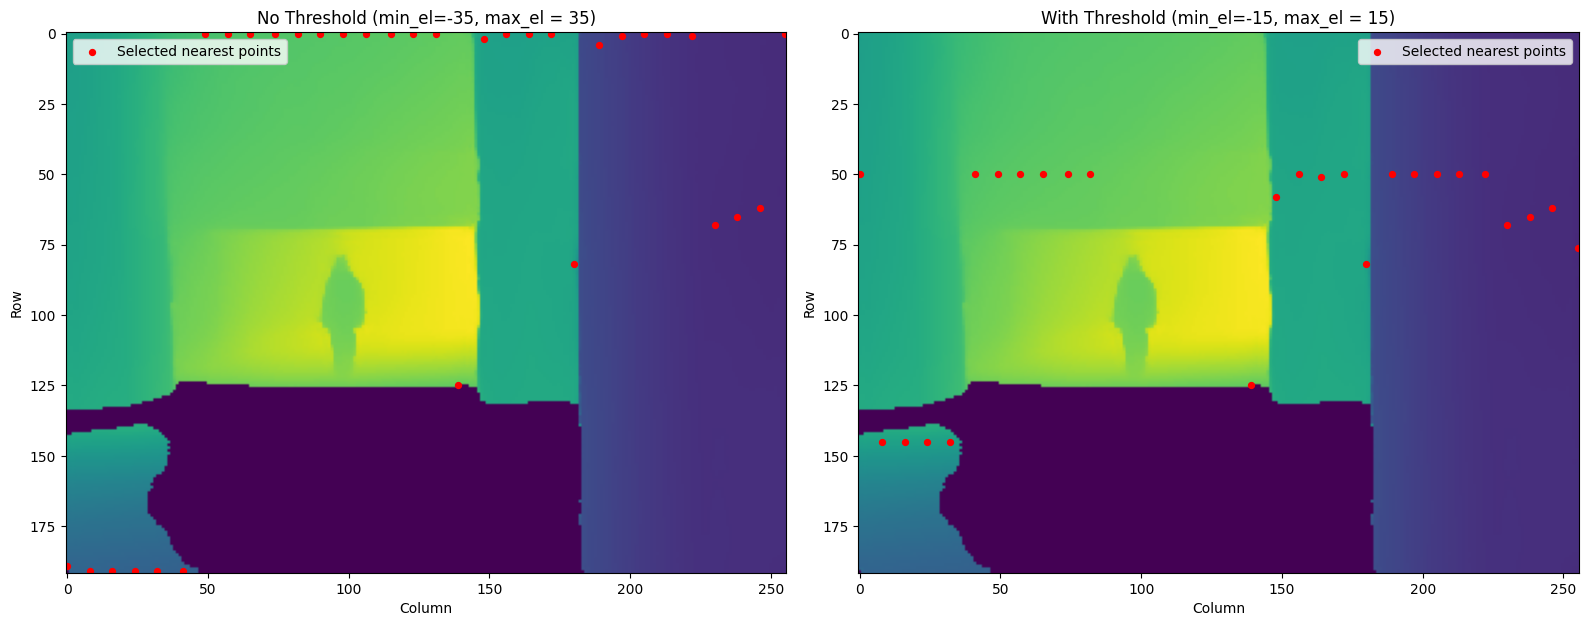

In [22]:
d = depths[0]

disp = depth_to_colormap(d)

# No threshold
near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(d) 

# With threshold
near_az1, near_el1, near_dist1, sel_cols1, sel_rows1 = extract_scan_points(d, min_elevation= -15, max_elevation = 15) 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Without threshold
axes[0].imshow(disp, cmap="viridis", origin="upper")
axes[0].scatter(sel_cols, sel_rows, c="red", s=18, label="Selected nearest points")
axes[0].set_title("No Threshold (min_el=-35, max_el = 35)")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
axes[0].legend()

# Plot 2: With threshold
axes[1].imshow(disp, cmap="viridis", origin="upper")
axes[1].scatter(sel_cols1, sel_rows1, c="red", s=18, label="Selected nearest points")
axes[1].set_title("With Threshold (min_el=-15, max_el = 15)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
axes[1].legend()

plt.tight_layout()
plt.show()

### Sweep-based sonification

The extracted scan points are converted into a time-based audio sweep.

For each scan position:
- a short audio ping is generated
- the ping is spatialized using HRTF (azimuth + elevation)
- the loudness is scaled based on distance
- the ping is placed at a specific time in the sweep

The result is a sequence of spatial audio cues moving from left to right across the field of view.

In [23]:
def build_sweep_hrtf(near_az, near_el, near_dist, sofa, 
                     tree, reverse=False, max_range=6.0,
                     sample_rate=48000, sweep_duration=2.0,
                     ping_dur=0.18):
    
    W = len(near_az)
    total_samples = int(sample_rate * sweep_duration)
    stereo = np.zeros((total_samples, 2), dtype=np.float32)

    if W == 0:
        return stereo

    idx_range = range(W - 1, -1, -1) if reverse else range(W)

    start_center = ping_dur / 2
    end_center = sweep_duration - ping_dur / 2

    for u, i in enumerate(idx_range):
        if W == 1:
            t_center = sweep_duration / 2
        else:
            t_center = start_center + (u / (W - 1)) * (end_center - start_center)

        s_start = max(int((t_center - ping_dur / 2) * sample_rate), 0)

        d = float(np.clip(near_dist[i], 0.0, max_range))

        ping = make_spatial_ping(azimuth=near_az[i],elevation=near_el[i],distance=d,
                                 sofa=sofa,tree=tree,sample_rate=sample_rate,
                                 max_range=max_range,dur=ping_dur)
        
        n = ping.shape[0]
        s_end = min(s_start + n, total_samples)
        n_write = s_end - s_start

        if n_write > 0:
            stereo[s_start:s_end] += ping[:n_write]

    peak = np.abs(stereo).max()
    if peak > 0:
        stereo /= peak

    return stereo

#### Listening test: forward and backward sweep

The following demonstrates the sweep-based sonification.

When listening with headphones:
- sounds move from left to right across the field of view
- closer objects appear louder
- elevation cues are present through HRTF spatialization

In [24]:
sweep_fwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=False
)

sweep_bwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=True
)

sd.play(sweep_fwd, 48000)
sd.wait()

sd.play(sweep_bwd, 48000)
sd.wait()

### Visual aid during sweep playback

To make the sweep easier to interpret, a synchronized visualization is shown during playback.

This function uses IPython display utilities to render a frame-synchronised visualisation during audio playback."

In [25]:
from IPython.display import display, clear_output

def play_sweep_with_inline_visual(d, sel_cols, sel_rows, near_az, 
                                  near_dist, sweep_audio, sample_rate=48000, 
                                  sweep_duration=4.0, reverse=False, fps=20):

    display_depth = depth_to_colormap(d)
    
    W = len(sel_cols)
    if W == 0:
        print("No scan points to display.")
        return

    sd.play(sweep_audio, samplerate=sample_rate)
    t0 = time.perf_counter()

    while True:
        elapsed = time.perf_counter() - t0
        frac = min(elapsed / sweep_duration, 1.0)

        idx = int(round(frac * (W - 1)))
        idx = np.clip(idx, 0, W - 1)

        if reverse:
            idx = (W - 1) - idx

        u = sel_cols[idx]
        v = sel_rows[idx]
        az = near_az[idx]
        dist = near_dist[idx]

        fig, (ax_img, ax_prof) = plt.subplots(2, 1, figsize=(8, 7))
        fig.suptitle("Sweep Visualization")

        # top panel
        im = ax_img.imshow(display_depth, cmap="viridis", origin="upper")
        ax_img.scatter(sel_cols, sel_rows, c="red", s=20)
        ax_img.axvline(u, color="white", linestyle="--", linewidth=1.5)
        ax_img.plot([u], [v], "wo", markersize=8)
        ax_img.set_title("Depth Frame")
        ax_img.set_xlabel("Column")
        ax_img.set_ylabel("Row")

        # bottom panel
        ax_prof.plot(near_az, near_dist, linewidth=1.5)
        ax_prof.axvline(az, color="tomato", linestyle="--", linewidth=1.5)
        ax_prof.plot([az], [dist], "ro")
        ax_prof.set_title("Nearest Distance vs Azimuth")
        ax_prof.set_xlabel("Azimuth (deg)")
        ax_prof.set_ylabel("Distance (m)")
        ax_prof.grid(True)

        plt.tight_layout()

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

        if elapsed >= sweep_duration:
            break

        time.sleep(1.0 / fps)

    sd.wait()

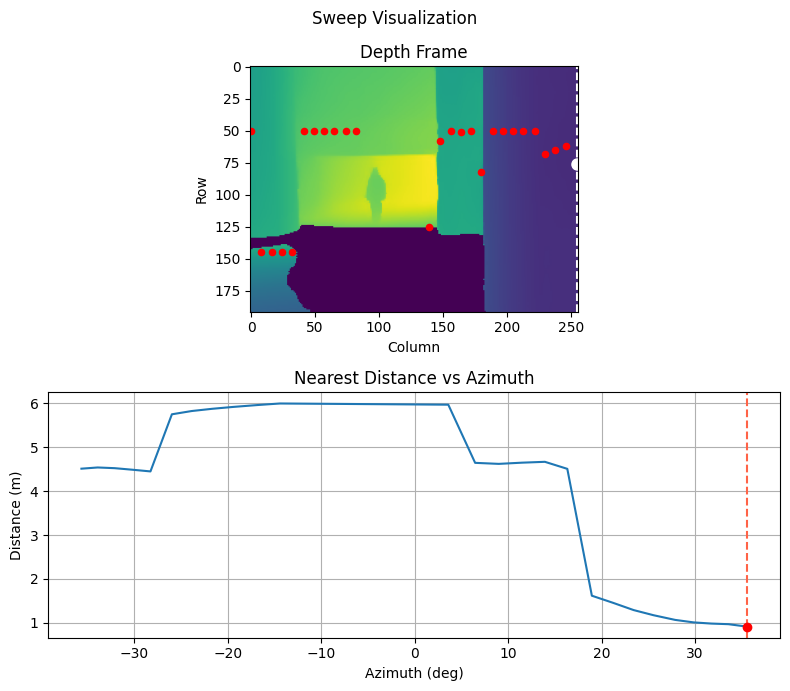

In [26]:
sweep_fwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=False,
    sweep_duration=4.0
)

near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(d,min_elevation= -15, max_elevation = 15)

play_sweep_with_inline_visual(
    d=d,
    sel_cols=sel_cols,
    sel_rows=sel_rows,
    near_az=near_az,
    near_dist=near_dist,
    sweep_audio=sweep_fwd,
    sample_rate=48000,
    sweep_duration=4.0,
    reverse=False,
    fps=15,
)

## 6. Frame-by-frame depth playback with sweep overlay

This section demonstrates a prototype integration of:
- recorded depth video
- sweep-based spatial sonification

For each depth frame:
1. the frame is displayed
2. a full forward sweep is played
3. a full backward sweep is played
4. the next frame is then processed

This is a simplified prototype design intended to clearly show the relationship between a single depth frame and its corresponding audio sweep.

In a future real-time version, depth updates and sweep generation should occur concurrently rather than sequentially. That will likely require multithreading or a similar asynchronous processing structure.

In [27]:
def play_depth_video_with_sweeps(depths, n_frames, sofa, tree, 
                                 max_range=6.0, min_elevation=-15.0, 
                                 max_elevation = 15.0, sample_rate=48000, 
                                 sweep_duration=4.0, ping_dur=0.04, 
                                 max_frames=None, frame_step = 10):
    
    if max_frames is not None:
        n_frames = min(n_frames, max_frames)

    for i in range(0, n_frames, frame_step):
        d = depths[i]

        d_color = depth_to_colormap(d, size=(512, 256))
        d_color = cv2.cvtColor(d_color, cv2.COLOR_RGB2BGR)

        # extract scan points from original depth frame
        near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(d = d, min_elevation = min_elevation, max_elevation = max_elevation)

        if len(near_az) == 0:
            cv2.imshow("Depth + Sweep", d_color)
            print(f"Frame {i}: no valid scan points found.")
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            continue

        # scale selected points to resized display
        h0, w0 = d.shape
        h1, w1 = d_color.shape[:2]

        sel_cols_vis = (sel_cols * (w1 / w0)).astype(int)
        sel_rows_vis = (sel_rows * (h1 / h0)).astype(int)

        # forward sweep
        sweep_fwd = build_sweep_hrtf(
            near_az, near_el, near_dist,
            sofa=sofa,
            tree=tree,
            reverse=False,
            max_range=max_range,
            sample_rate=sample_rate,
            sweep_duration=sweep_duration,
            ping_dur=ping_dur,
        )

        # show frame before sweep
        frame_vis = d_color.copy()
        for u, v in zip(sel_cols_vis, sel_rows_vis):
            cv2.circle(frame_vis, (u, v), 2, (0, 0, 255), -1)

        cv2.putText(frame_vis, f"Frame {i} - Forward Sweep", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        cv2.imshow("Depth + Sweep", frame_vis)
        cv2.waitKey(1)

        sd.play(sweep_fwd, samplerate=sample_rate)
        t0 = time.perf_counter()

        while True:
            elapsed = time.perf_counter() - t0
            frac = min(elapsed / sweep_duration, 1.0)

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = np.clip(idx, 0, len(sel_cols_vis) - 1)

            vis = frame_vis.copy()
            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]

            cv2.line(vis, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(vis, (u, v), 5, (255, 255, 255), -1)

            cv2.imshow("Depth + Sweep", vis)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                sd.stop()
                cv2.destroyWindow("Depth + Sweep")
                return

            if elapsed >= sweep_duration:
                break

        sd.wait()

        # backward sweep
        sweep_bwd = build_sweep_hrtf(
            near_az, near_el, near_dist,
            sofa=sofa,
            tree=tree,
            reverse=True,
            max_range=max_range,
            sample_rate=sample_rate,
            sweep_duration=sweep_duration,
            ping_dur=ping_dur,
        )

        frame_vis = d_color.copy()
        for u, v in zip(sel_cols_vis, sel_rows_vis):
            cv2.circle(frame_vis, (u, v), 2, (0, 0, 255), -1)

        cv2.putText(frame_vis, f"Frame {i} - Backward Sweep", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        cv2.imshow("Depth + Sweep", frame_vis)
        cv2.waitKey(1)

        sd.play(sweep_bwd, samplerate=sample_rate)
        t0 = time.perf_counter()

        while True:
            elapsed = time.perf_counter() - t0
            frac = min(elapsed / sweep_duration, 1.0)

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = np.clip(idx, 0, len(sel_cols_vis) - 1)
            idx = (len(sel_cols_vis) - 1) - idx

            vis = frame_vis.copy()
            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]

            cv2.line(vis, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(vis, (u, v), 5, (255, 255, 255), -1)

            cv2.imshow("Depth + Sweep", vis)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                sd.stop()
                cv2.destroyWindow("Depth + Sweep")
                return

            if elapsed >= sweep_duration:
                break

        sd.wait()

    cv2.destroyWindow("Depth + Sweep")

In [28]:
play_depth_video_with_sweeps(
    depths=depths,
    n_frames=frames,
    sofa=SOFA,
    tree=tree,
    max_range=6.0,
    min_elevation=-15.0,
    max_elevation = 15.0,
    sample_rate=48000,
    sweep_duration=2,
    ping_dur=0.18,
    max_frames=1000,
    frame_step = 100
)

#### Limitation

In this prototype, each frame is held fixed while a full forward and backward sweep is completed.

This makes the mapping between one frame and one sweep easy to inspect, but it is not yet real-time.

In a future real-time system:
- new depth frames should continue arriving while the sweep is being played
- audio generation and visual/depth updates should run concurrently
- this will likely require threading or another asynchronous design

## 7. Semi Real-time depth sonification

This section brings together everything from the previous sections into a semi-real-time simulation.

The goal is to simulate real-time recording while sonification is happening continuously. Depth frames play at 60 fps, and an audio sweep runs independently, always reading from whatever frame is currently on screen.

### Design overview

Two threads run concurrently:

**Video thread** — Advances through depth frames at 60 fps. Each frame is colorized and displayed. It writes the current frame index into a small shared state dictionary so the audio thread always knows which frame is on screen.

**Audio thread** — Runs an infinite sweep loop. At the start of each new sweep it reads the current frame index from shared state, builds a full stereo sweep buffer for that frame using `build_sweep_hrtf`, and plays it. While that sweep is playing it immediately starts building the next one in a background thread so it is ready before the current one ends. When the two sweeps meet, a short crossfade blends them together so the transition is seamless. The direction alternates forward → backward → forward on every sweep.

### Shared state

The two threads share only a small dictionary protected by a lock:

```
state = {
    "current_frame_idx"  — written by video thread, read by audio thread
    "running"            — set to False when video ends or user presses Q
    "sweep_start_time"   — written by audio thread so video thread can draw the sweep line
    "sweep_duration"     — written by audio thread
    "sweep_direction"    — written by audio thread (+1 forward, -1 backward)
}
```

The video thread uses `sweep_start_time`, `sweep_duration`, and `sweep_direction` to compute where the sweep line should be drawn each frame, without needing to talk to the audio thread directly.

### Step 1 — Precompute scan data

Scan points (azimuth, elevation, distance) are extracted for every frame ahead of time. This is the same `precompute_scan_data` function used in section 8. It only needs to be run once then the result is reused across all simulations.

In [29]:
def precompute_scan_data(depths, n_frames, max_range=6.0, min_elevation= -15.0, 
                         max_elevation = 15.0, num_cols=32):
    
    all_scan_data = []

    for i in range(n_frames):
        d = depths[i]

        near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(
            d,
            num_cols=num_cols,
            max_range=max_range,
            min_elevation=min_elevation,
            max_elevation=max_elevation
        )

        all_scan_data.append({
            "near_az": near_az,
            "near_el": near_el,
            "near_dist": near_dist,
            "sel_cols": sel_cols,
            "sel_rows": sel_rows
        })

        if i % 100 == 0:
            print(f"Precomputed frame {i}/{n_frames}")

    return all_scan_data

In [30]:
all_scan_data = precompute_scan_data(
    depths = depths,
    n_frames = frames,
    max_range = 6.0,
    min_elevation = -15.0,
    max_elevation = 15.0,
)

Precomputed frame 0/978
Precomputed frame 100/978
Precomputed frame 200/978
Precomputed frame 300/978
Precomputed frame 400/978
Precomputed frame 500/978
Precomputed frame 600/978
Precomputed frame 700/978
Precomputed frame 800/978
Precomputed frame 900/978


### Step 2 — Shared state

A small dictionary is shared between threads. The lock ensures neither thread reads half-written values.

In [31]:
state = {
    "current_frame_idx": 0,
    "running": True,
    "sweep_start_time": time.perf_counter(),
    "sweep_duration": 2.0,
    "sweep_direction": 1,
}
state_lock = threading.Lock()

### Step 3 — Video thread

Advances through every depth frame at the target fps. Each iteration:
1. writes the current frame index to shared state
2. colorizes the depth frame
3. draws the scan point dots
4. reads sweep timing from shared state and computes the sweep line position
5. draws the sweep line and displays the frame
6. sleeps for the remainder of the frame budget

The sweep line position is computed purely from elapsed time leaving no need for communication with the audio thread beyond reading three numbers from shared state.

In [32]:
def video_loop(depths, n_frames, all_scan_data, state, state_lock, fps=60.0):
    frame_time = 1.0 / fps

    for i in range(n_frames):
        frame_start = time.perf_counter()

        with state_lock:
            if not state["running"]:
                break

            state["current_frame_idx"] = i
            sweep_start = state["sweep_start_time"]
            sweep_dur = state["sweep_duration"]
            sweep_dir = state["sweep_direction"]

        d = depths[i]

        d_color = depth_to_colormap(d, size=(512, 256))
        d_color = cv2.cvtColor(d_color, cv2.COLOR_RGB2BGR)

        scan = all_scan_data[i]
        sel_cols = scan["sel_cols"]
        sel_rows = scan["sel_rows"]

        h0, w0 = d.shape
        h1, w1 = d_color.shape[:2]

        if len(sel_cols) > 0:
            sel_cols_vis = (sel_cols * (w1 / w0)).astype(int)
            sel_rows_vis = (sel_rows * (h1 / h0)).astype(int)

            for u, v in zip(sel_cols_vis, sel_rows_vis):
                cv2.circle(d_color, (u, v), 1, (0, 0, 255), -1)

            elapsed = time.perf_counter() - sweep_start
            frac = float(np.clip(elapsed / sweep_dur, 0.0, 1.0))

            if sweep_dir == -1:
                frac = 1.0 - frac

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = int(np.clip(idx, 0, len(sel_cols_vis) - 1))

            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]

            cv2.line(d_color, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(d_color, (u, v), 5, (255, 255, 255), -1)

        sweep_txt = "Forward" if sweep_dir == 1 else "Backward"

        cv2.putText(
            d_color,
            f"Frame {i} - {sweep_txt}",
            (10, 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

        cv2.imshow("Realtime Depth Sonification", d_color)

        elapsed = time.perf_counter() - frame_start
        remaining_ms = max(1, int((frame_time - elapsed) * 1000))

        if cv2.waitKey(remaining_ms) & 0xFF == ord("q"):
            with state_lock:
                state["running"] = False
            break

    with state_lock:
        state["running"] = False

    cv2.destroyWindow("Realtime Depth Sonification")

### Step 4 — Audio thread

Runs a continuous sweep loop with crossfading between sweeps.

**Each iteration:**
1. Reads the current frame index and builds the current sweep (if first iteration) or uses the pre-built one from the previous iteration
2. Immediately kicks off a background thread to pre-build the next sweep while the current one plays
3. Plays the current sweep through a persistent `OutputStream` whose callback mixes the outgoing and incoming buffers during the crossfade window
4. Waits until the crossfade is complete, then promotes the next sweep to current and flips direction

**The callback** is the heart of the crossfade. It runs on the audio hardware thread every ~10ms (512 samples at 48kHz). It tracks two states:
- **Plain playback** (`cf_pos == -1`): copies samples from the current buffer directly to output
- **Crossfade** (`cf_pos >= 0`): mixes current (fading out with cos²) and next (fading in with sin²) until `cf_pos` reaches `cf_samples` or the current buffer is exhausted, whichever comes first, then promotes next → current

The cos²/sin² pair is a standard equal-power crossfade: at any point during the fade `cos²(t) + sin²(t) = 1`, so the total loudness stays constant and there is no audible dip.

In [141]:
def build_sweep(scan, reverse, sofa, tree, max_range=2.0, sample_rate=48000, sweep_duration=2.0, ping_dur=0.18, ):    
    if len(scan["near_az"]) == 0:
        return None

    return build_sweep_hrtf(
        scan["near_az"],
        scan["near_el"],
        scan["near_dist"],
        sofa=sofa,
        tree=tree,
        reverse=reverse,
        max_range=max_range,
        sample_rate=sample_rate,
        sweep_duration=sweep_duration,
        ping_dur=ping_dur,
    )

In [142]:
def sweep_audio_loop( all_scan_data, sofa, tree, state, state_lock, cue_events=None, cue_lock=None, 
                     sample_rate=48000, sweep_duration=2.0, ping_dur=0.18, max_range=2.0, 
                     crossfade=0.2, blocksize=512):
    
    cf_samples = int(crossfade * sample_rate)

    cb = {
        "current": None,
        "next": None,
        "pos": 0,
        "cf_pos": -1,
        "promoted": False,
        "direction": 1,
    }

    cb_lock = threading.Lock()

    def callback(outdata, frames, time_info, status):
        out = np.zeros((frames, 2), dtype=np.float32)

        with cb_lock:
            cur = cb["current"]
            nxt = cb["next"]
            pos = cb["pos"]
            cf_pos = cb["cf_pos"]

            if cur is not None:
                remaining = len(cur) - pos

                if nxt is not None and cf_pos == -1 and remaining <= cf_samples:
                    cb["cf_pos"] = 0
                    cf_pos = 0

                if cf_pos == -1:
                    n = min(frames, remaining)

                    if n > 0:
                        out[:n] += cur[pos:pos + n]

                    cb["pos"] = pos + n

                    if cb["pos"] >= len(cur) and nxt is None:
                        cb["current"] = None

                else:
                    n_cur = max(len(cur) - pos, 0)
                    n_nxt = max(len(nxt) - cf_pos, 0)
                    n = min(frames, max(n_cur, n_nxt))

                    if n > 0:
                        t = np.linspace(cf_pos, cf_pos + n - 1, n) / cf_samples
                        t = np.clip(t, 0.0, 1.0)

                        fade_out = (np.cos(t * np.pi / 2) ** 2).reshape(-1, 1)
                        fade_in = (np.sin(t * np.pi / 2) ** 2).reshape(-1, 1)

                        cur_chunk = np.zeros((n, 2), dtype=np.float32)
                        nxt_chunk = np.zeros((n, 2), dtype=np.float32)

                        if n_cur > 0:
                            take = min(n, n_cur)
                            cur_chunk[:take] = cur[pos:pos + take]

                        if n_nxt > 0:
                            take = min(n, n_nxt)
                            nxt_chunk[:take] = nxt[cf_pos:cf_pos + take]

                        out[:n] += cur_chunk * fade_out + nxt_chunk * fade_in

                    cb["cf_pos"] = cf_pos + n
                    cb["pos"] = pos + n

                    if cb["cf_pos"] >= cf_samples or cb["pos"] >= len(cur):
                        cb["current"] = nxt
                        cb["next"] = None
                        cb["pos"] = cb["cf_pos"]
                        cb["cf_pos"] = -1
                        cb["direction"] *= -1
                        cb["promoted"] = True

        if cue_events is not None and cue_lock is not None:
            mix_click_events(out, cue_events, cue_lock)

        peak = np.max(np.abs(out))
        if peak > 1.0:
            out /= peak

        outdata[:] = out

    stream = sd.OutputStream(
        samplerate=sample_rate,
        channels=2,
        dtype="float32",
        blocksize=blocksize,
        callback=callback,
    )

    stream.start()

    with state_lock:
        frame_idx = state["current_frame_idx"]

    first = build_sweep(all_scan_data[frame_idx], reverse=False, sofa=sofa, tree=tree, max_range=max_range, 
                        sample_rate=sample_rate,sweep_duration=sweep_duration,ping_dur=ping_dur)

    with cb_lock:
        cb["current"] = first
        cb["pos"] = 0

    with state_lock:
        state["sweep_start_time"] = time.perf_counter()
        state["sweep_duration"] = sweep_duration
        state["sweep_direction"] = 1

    next_queued = False

    try:
        while True:
            with state_lock:
                if not state["running"]:
                    break

                frame_idx = state["current_frame_idx"]

            frame_idx = int(np.clip(frame_idx, 0, len(all_scan_data) - 1))

            with cb_lock:
                cur = cb["current"]
                pos = cb["pos"]
                promoted = cb["promoted"]
                direction = cb["direction"]
                has_next = cb["next"] is not None

            if promoted:
                with cb_lock:
                    cb["promoted"] = False

                next_queued = False

                with state_lock:
                    state["sweep_start_time"] = time.perf_counter()
                    state["sweep_duration"] = sweep_duration
                    state["sweep_direction"] = direction

            if cur is None and not has_next:
                new_sweep = build_sweep(all_scan_data[frame_idx], reverse=(direction == -1), sofa=sofa, tree=tree, max_range=max_range, 
                                        sample_rate=sample_rate, sweep_duration=sweep_duration, ping_dur=ping_dur,)

                if new_sweep is not None:
                    with cb_lock:
                        cb["current"] = new_sweep
                        cb["pos"] = 0
                        cb["cf_pos"] = -1

                    next_queued = False

                    with state_lock:
                        state["sweep_start_time"] = time.perf_counter()
                        state["sweep_duration"] = sweep_duration
                        state["sweep_direction"] = direction

            elif cur is not None and not next_queued and not has_next:
                remaining_s = (len(cur) - pos) / sample_rate

                if remaining_s < crossfade + 0.4:
                    next_sweep = build_sweep(all_scan_data[frame_idx], reverse=(direction == +1), sofa=sofa, tree=tree, max_range=max_range, 
                                        sample_rate=sample_rate, sweep_duration=sweep_duration, ping_dur=ping_dur,)

                    if next_sweep is not None:
                        with cb_lock:
                            cb["next"] = next_sweep

                    next_queued = True

            time.sleep(0.02)

    finally:
        stream.stop()
        stream.close()

In [143]:
def audio_loop(all_scan_data, sofa, tree, state, state_lock,
               sample_rate=48000, sweep_duration=2.0, ping_dur=0.18,
               max_range=2.0):

    sweep_audio_loop(all_scan_data=all_scan_data, sofa=sofa, tree=tree, state=state, state_lock=state_lock, 
                     cue_events=None, cue_lock=None, sample_rate=sample_rate, sweep_duration=sweep_duration, 
                     ping_dur=ping_dur, max_range=max_range,)

### Step 5 — Run

Launches both threads and waits for them to finish. Press **Q** in the video window to stop.

Parameters to tune:
- `sweep_duration` — how long one left-to-right (or right-to-left) sweep takes in seconds
- `ping_dur` — duration of each individual spatial ping; should be ≥ `sweep_duration / n_scan_cols` for continuous sound
- `crossfade` — overlap between consecutive sweeps in seconds; 0.2–0.4 works well
- `fps` — video playback rate

In [144]:
def run_realtime_simulation(depths, n_frames, all_scan_data, sofa, tree, fps=60.0, 
                            sample_rate=48000, sweep_duration=2.0, ping_dur=0.18, 
                            max_range=6.0,):
    
    with state_lock:
        state["current_frame_idx"] = 0
        state["running"] = True

    video_thread = threading.Thread(
        target=video_loop,
        args=(depths, n_frames, all_scan_data, state, state_lock, fps),
        daemon=True
    )
    audio_thread = threading.Thread(
        target=audio_loop,
        args=(all_scan_data, sofa, tree, state, state_lock,
              sample_rate, sweep_duration, ping_dur, max_range),
        daemon=True
    )

    video_thread.start()
    audio_thread.start()

    video_thread.join()
    audio_thread.join()

#### Testing

You can test the player with this and feel free to tweak the settings for different results

In [145]:
run_realtime_simulation(
    depths=depths,
    n_frames=frames,
    all_scan_data=all_scan_data,
    sofa=SOFA,
    tree=tree,
    fps=60.0,
    sample_rate=48000,
    sweep_duration=2.0,   # same as the working frame-by-frame call
    ping_dur=0.18,        # same as the working frame-by-frame call
    max_range=4.0,
)

## 8. Hazard Detection and Motion Tracking

This section detects nearby obstacles in the depth stream and tracks them across frames.
It extends the previous depth-processing pipeline with four additional stages:

1. **Hazard masking**: keep only pixels in a useful depth and field-of-view range.
2. **Depth clustering**: group neighboring pixels that likely belong to the same physical object.
3. **Frame-to-frame association**: use the Hungarian algorithm to match current clusters to existing tracks.
4. **Motion estimation**: use a Kalman filter to smooth each tracked object's position and estimate its velocity.

The output is a real-time visualization where each detected object is marked as:

- **STATIC**: stable obstacle or background structure
- **MOVING**: object with sustained ground-plane motion
- **CAMERA PAN**: camera motion is high enough that object velocity is temporarily unreliable

The tracking pipeline is designed to run alongside the spatial-audio sweep. Because the audio loop will add extra work, the expensive clustering step is accelerated with Numba and camera poses are cached once instead of reading the metadata file every frame.


### Hazard Region Mask

The first step is to discard pixels that cannot represent an immediate navigation hazard.
A depth pixel is kept only if it lies inside both a depth interval and a forward-facing angular region.

Let a depth pixel be indexed by image coordinates $(u,v)$, where $u$ is the column and $v$ is the row. The measured depth is:

$$
D(u,v)
$$

The pixel is valid only when its depth is finite and lies inside the selected operating range:

$$
D_{min} < D(u,v) < D_{max}
$$

The column index $u$ has a corresponding horizontal viewing angle, or azimuth:

$$
\theta(u)
$$

The row index $v$ has a corresponding vertical viewing angle, or elevation:

$$
\phi(v)
$$

The field-of-view constraint is therefore:

$$
\theta_{min} \leq \theta(u) \leq \theta_{max}
$$

$$
\phi_{min} \leq \phi(v) \leq \phi_{max}
$$

Combining these conditions gives the binary hazard mask:

$$
M(u,v) =
\begin{cases}
1, & D_{min} < D(u,v) < D_{max} \\
   & \land\; \theta_{min} \leq \theta(u) \leq \theta_{max} \\
   & \land\; \phi_{min} \leq \phi(v) \leq \phi_{max} \\
0, & \text{otherwise}
\end{cases}
$$

This keeps the central forward-facing region and removes invalid, very close, very far, or out-of-view pixels before clustering begins.


In [56]:
def create_hazard_mask(depth, azimuths, elevations, confidence=None, min_depth=0.3, max_depth=4.0, 
                       min_azimuth=-30, max_azimuth=30, min_elevation=-8, max_elevation=15,
                       min_confidence=1):
    
    valid_depth = np.isfinite(depth) & (depth > min_depth) & (depth < max_depth)

    az_mask = (azimuths >= min_azimuth) & (azimuths <= max_azimuth)
    el_mask = (elevations >= min_elevation) & (elevations <= max_elevation)

    # Convert 1D angle masks into 2D masks
    fov_mask = el_mask[:, None] & az_mask[None, :]

    mask = valid_depth & fov_mask

    if confidence is not None:
        mask &= confidence >= min_confidence

    return mask

In [63]:
def show_mask_debug(depth, hazard_mask):
    plt.figure(figsize=(6, 5))
    plt.imshow(depth, cmap="viridis")
    plt.title("Raw depth")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.imshow(hazard_mask, cmap="viridis")
    plt.title("Hazard mask")
    plt.colorbar()
    plt.show()

#### Mask Debug Example

The following debug cell visualizes:

1. the raw depth frame,
2. the hazard mask before cleanup,
3. the hazard mask after small connected components are removed.

This is useful for verifying that the selected field-of-view and depth limits are reasonable before applying object clustering.


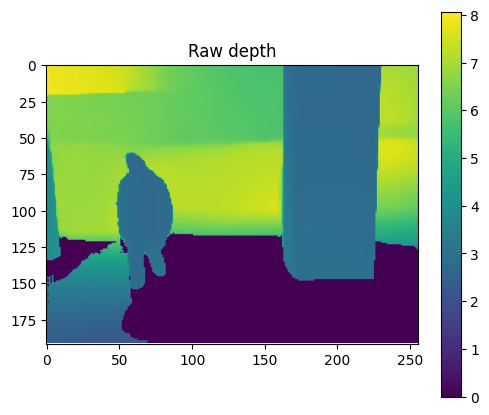

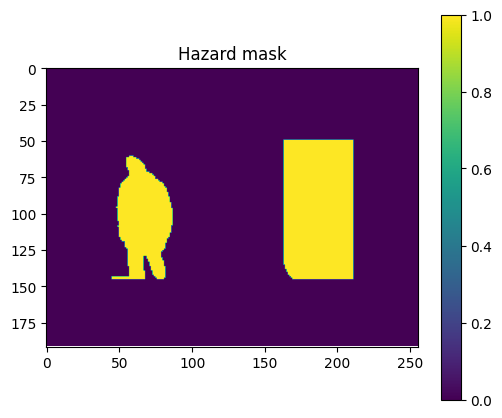

In [72]:
d = depths[230]

hazard_mask = create_hazard_mask(
    d,
    AZI,
    ELV,
    confidence=None,
    min_depth=0.3,
    max_depth=4.0,
    min_azimuth=-25,
    max_azimuth=25,
    min_elevation=-15,
    max_elevation=15,
    min_confidence=1
)

show_mask_debug(d, hazard_mask)

### Depth-Based Connected Clustering

After masking, neighboring pixels are grouped into object candidates.
The clustering assumes that pixels belonging to the same physical object are usually connected in the image and have locally similar depth.

For two neighboring pixels $p_i$ and $p_j$, the depth difference is:

$$
\Delta D = |D(p_i) - D(p_j)|
$$

The pixels are allowed to join the same cluster iff:

$$
\Delta D < 	\tau(D(p_i))
$$

The threshold is depth-adaptive:

$$
	\tau(D) = 	\tau_0 + kD
$$

where:

- $	au_0$ is the base depth tolerance,
- $k$ controls how much tolerance increases with distance,
- $D$ is the current pixel depth.

This matters because depth noise generally increases as objects get farther away. A fixed threshold can over-segment far objects, while a depth-adaptive threshold is more forgiving at longer range.

The algorithm uses 4-neighbor connectivity:

$$
\mathcal{N}_4(u,v) = \{(u-1,v), (u+1,v), (u,v-1), (u,v+1)\}
$$

A standard connected-components API, such as a binary mask labeler, is not enough here because it would only check whether neighboring pixels are inside the mask. This clustering also needs to check the local depth jump before accepting a neighbor. For that reason, the notebook keeps one custom depth-aware flood fill and compiles it with Numba. The public function `connected_depth_clustering` always calls the compiled implementation.


In [65]:
if not NUMBA_AVAILABLE:
    raise ImportError(
        "Numba is required for connected_depth_clustering in this notebook. "
        "Install numba before running the real-time tracking sections."
    )
    
@njit
def connected_depth_clustering(depth, mask, base_thresh, scale_thresh):
    h, w = depth.shape
    labels = np.zeros((h, w), dtype=np.int32)
    stack_y = np.empty(h * w, dtype=np.int32)
    stack_x = np.empty(h * w, dtype=np.int32)
    current_label = 0

    # 4-Neighborhood definition
    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for y in range(h):
        for x in range(w):
            if not mask[y, x] or labels[y, x] != 0:
                continue

            current_label += 1
            top = 0
            stack_y[top] = y
            stack_x[top] = x
            labels[y, x] = current_label

            while top >= 0:
                cy = stack_y[top]
                cx = stack_x[top]
                top -= 1

                current_depth = depth[cy, cx]
                threshold = base_thresh + scale_thresh * current_depth

                for dy, dx in offsets:
                    ny, nx = cy + dy, cx + dx

                    # Boundary and Mask Check
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and labels[ny, nx] == 0:
                        # Depth Similarity Check
                        if abs(depth[ny, nx] - current_depth) < threshold:
                            labels[ny, nx] = current_label
                            top += 1
                            stack_y[top], stack_x[top] = ny, nx

    return labels

### Cluster Size Filtering

Very small clusters are usually noise, edge fragments, or isolated depth artifacts. After connected clustering, each cluster label $k$ has a pixel count:

$$
N_k = \sum_{u,v} \mathbb{1}[L(u,v)=k]
$$

A cluster is kept only when:

$$
N_k \geq N_{min}
$$

The remaining labels are compactly relabeled as:

$$
1, 2, 3, \ldots, K
$$

This keeps later visualization and feature extraction simple, because the active cluster labels are dense and start from one.


In [66]:
def remove_small_clusters(labels, min_pixels=100):
    sizes = np.bincount(labels.ravel())
    if len(sizes) <= 1:
        return np.zeros_like(labels, dtype=np.int32)

    keep = sizes >= min_pixels
    keep[0] = False
    kept_labels = np.flatnonzero(keep)

    relabel = np.zeros(len(sizes), dtype=np.int32)
    relabel[kept_labels] = np.arange(1, len(kept_labels) + 1, dtype=np.int32)

    return relabel[labels]

### Cluster Statistics and 3D Centroids

Each cluster is summarized using both image-space and camera-space features.
For a pixel $(u,v)$ with depth $Z = D(u,v)$, the pinhole camera model maps the pixel into 3D camera coordinates.

The horizontal coordinate is:

$$
X = \frac{(u - c_x)Z}{f_x}
$$

The vertical coordinate is:

$$
Y = -\frac{(v - c_y)Z}{f_y}
$$

The forward coordinate is simply:

$$
Z = -D(u,v)
$$

The negative sign in $Y$ makes upward image motion correspond to positive camera-space height. The negative sign in $Z$ is becuase iPhone lidar depth data exports forward direction as negative.

For a cluster containing pixels $\mathcal{C}_k$, the camera-space centroid is computed using medians:

$$
\mathbf{p}_{cam,k} =
\begin{bmatrix}
\operatorname{median}_{(u,v)\in\mathcal{C}_k}(X(u,v)) \\
\operatorname{median}_{(u,v)\in\mathcal{C}_k}(Y(u,v)) \\
\operatorname{median}_{(u,v)\in\mathcal{C}_k}(Z(u,v))
\end{bmatrix}
$$

The image-space centroid is also stored:

$$
\mathbf{q}_k =
\begin{bmatrix}
\operatorname{median}_{(u,v)\in\mathcal{C}_k}(u) \\
\operatorname{median}_{(u,v)\in\mathcal{C}_k}(v)
\end{bmatrix}
$$

Medians are used instead of means because depth clusters often contain edge noise, holes, and partial-object surfaces. A median is less sensitive to a few bad pixels at the cluster boundary.

For each cluster, the system stores:

- image centroid $\mathbf{q}_k$
- camera-space centroid $\mathbf{p}_{cam,k}$
- median depth
- nearest depth
- pixel count
- bounding box


In [73]:
def compute_cluster_features(labels, depth, fx_d=None, fy_d=None, cx_d=None, cy_d=None):
    clusters = []

    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != 0]

    for label in unique_labels:
        ys, xs = np.where(labels == label)
        zs = depth[ys, xs]

        valid = np.isfinite(zs) & (zs > 0)
        if np.sum(valid) == 0:
            continue

        xs = xs[valid]
        ys = ys[valid]
        zs = zs[valid]

        centroid_2d = np.array([np.median(xs),np.median(ys)], dtype=np.float32)

        bbox = np.array([np.min(xs), np.min(ys), np.max(xs), np.max(ys)], dtype=np.float32)
        
        cluster = {
            "label": int(label),
            "cx": float(centroid_2d[0]),
            "cy": float(centroid_2d[1]),
            "centroid_2d": centroid_2d,
            "num_pixels": int(len(xs)),
            "min_depth": float(np.min(zs)),
            "median_depth": float(np.median(zs)),
            "mean_depth": float(np.mean(zs)),
            "max_depth": float(np.max(zs)),
            "bbox": bbox,
        }

        if fx_d is not None and fy_d is not None and cx_d is not None and cy_d is not None:
            X = (xs - cx_d) * zs / fx_d
            Y = -(ys - cy_d) * zs / fy_d
            Z = zs
            cluster["centroid_3d"] = np.array([np.median(X),np.median(Y),np.median(Z)], dtype=np.float32)

        clusters.append(cluster)

    return clusters


def get_cluster_stats(labels, depth):
    return compute_cluster_features(labels, depth)


def compute_cluster_centroids_2d_3d(labels, depth, fx_d, fy_d, cx_d, cy_d):
    return compute_cluster_features(labels, depth, fx_d, fy_d, cx_d, cy_d)

In [74]:
def show_clusters(labels, depth):
    display = labels.astype(float).copy()
    display[display == 0] = np.nan

    stats = get_cluster_stats(labels, depth)

    plt.figure(figsize=(8, 6))
    plt.imshow(display, cmap="nipy_spectral", interpolation="nearest")
    plt.title("Clusters with depth")
    plt.colorbar(label="Cluster label")

    for s in stats:
        x = s["cx"]
        y = s["cy"]

        text = (
            f"ID {s['label']}\n"
            f"med {s['median_depth']:.2f}m\n"
            f"near {s['min_depth']:.2f}m"
        )

        plt.scatter(x, y, s=45, c="red", marker="o")
        plt.text(
            x + 3,
            y,
            text,
            color="white",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.6, edgecolor="none")
        )

    plt.show()

#### Cluster Debug Example

This cell runs the complete mask-cluster-filter-centroid pipeline on one frame and displays the labeled clusters.
It is intended as a still-frame sanity check before running the video tracker.


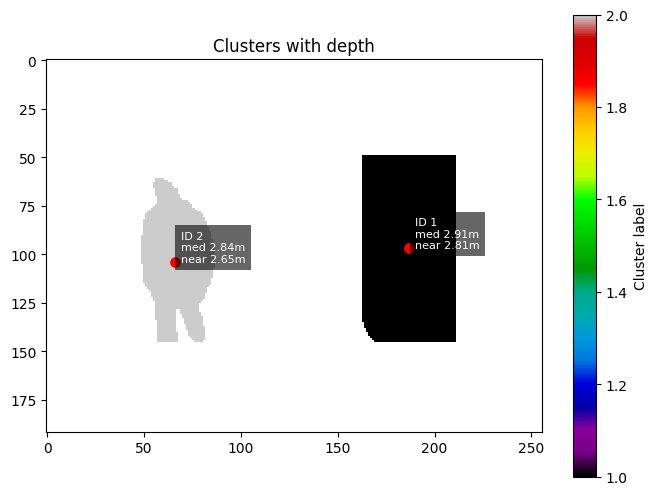

In [81]:
d = depths[230]

hazard_mask = create_hazard_mask(
    d,
    AZI,
    ELV,
    confidence=None,
    min_depth=0.3,
    max_depth=4.0,
    min_azimuth=-25,
    max_azimuth=25,
    min_elevation=-15,
    max_elevation=15,
    min_confidence=1
)

labels = connected_depth_clustering(d, hazard_mask, base_thresh=0.08, scale_thresh=0.05)
labels_clean = remove_small_clusters(labels, min_pixels=100)

show_clusters(labels_clean, d)

### Cluster Playback Visualization

For video playback, cluster labels are converted to colors using a small lookup table rather than calling a full OpenCV colormap over the entire frame each time.

If $L(u,v)$ is the cluster label image, the displayed color image is:

$$
I_{color}(u,v) = P[L(u,v)]
$$

where $P$ is a precomputed color palette. Label zero is reserved for the background and is displayed as black.

This keeps rendering inexpensive enough to leave CPU headroom for the spatial-audio sweep.


In [47]:
def labels_to_color_image(labels):
    if not hasattr(labels_to_color_image, "palette"):
        label_values = (np.arange(256, dtype=np.uint8) * 10).astype(np.uint8)
        labels_to_color_image.palette = cv2.applyColorMap(label_values.reshape(-1, 1), cv2.COLORMAP_TURBO)[:, 0, :]
        labels_to_color_image.palette[0] = 0

    labels_uint8 = labels.astype(np.uint8, copy=False)
    return labels_to_color_image.palette[labels_uint8].copy()

In [77]:
def detect_hazard_clusters(depth, azimuths, elevations, min_depth=0.3, max_depth=4.0, min_azimuth=-25, max_azimuth=25, 
                           min_elevation=-15, max_elevation=15, base_thresh=0.03, scale_thresh=0.01, 
                           min_cluster_pixels=100, fx_d=None, fy_d=None, cx_d=None, cy_d=None,):
    
    hazard_mask = create_hazard_mask(
        depth,
        azimuths,
        elevations,
        confidence=None,
        min_depth=min_depth,
        max_depth=max_depth,
        min_azimuth=min_azimuth,
        max_azimuth=max_azimuth,
        min_elevation=min_elevation,
        max_elevation=max_elevation,
        min_confidence=1,
    )

    labels = connected_depth_clustering(depth,hazard_mask,base_thresh=base_thresh,scale_thresh=scale_thresh,)

    labels_clean = remove_small_clusters(labels, min_pixels=min_cluster_pixels)

    clusters = compute_cluster_features(labels_clean,depth, fx_d, fy_d, cx_d, cy_d)

    return hazard_mask, labels_clean, clusters

In [78]:
def play_clustering_video(depths, AZI, ELV, start_frame=0, end_frame=None, target_fps=60, 
                          min_depth=0.3, max_depth=4.0, min_azimuth=-25, max_azimuth=25,
                          min_elevation=-15, max_elevation=15, base_thresh=0.03, 
                          scale_thresh=0.01, min_cluster_pixels=100,):
    
    if end_frame is None:
        end_frame = len(depths)

    start_frame = max(0, start_frame)
    end_frame = min(end_frame, len(depths))

    if start_frame >= end_frame:
        print("No frames to play.")
        return

    frame_time = 1.0 / target_fps
    fps_times = []
    window_name = "Depth clustering"

    try:
        for frame_idx in range(start_frame, end_frame):
            t0 = time.perf_counter()
            depth = depths[frame_idx]

            _, labels_clean, _ = detect_hazard_clusters(
                depth,
                AZI,
                ELV,
                min_depth=min_depth,
                max_depth=max_depth,
                min_azimuth=min_azimuth,
                max_azimuth=max_azimuth,
                min_elevation=min_elevation,
                max_elevation=max_elevation,
                base_thresh=base_thresh,
                scale_thresh=scale_thresh,
                min_cluster_pixels=min_cluster_pixels,
            )

            vis = labels_to_color_image(labels_clean)

            elapsed = time.perf_counter() - t0
            fps = 1.0 / elapsed if elapsed > 0 else 0.0
            fps_times.append(fps)

            cv2.putText(
                vis,
                f"Frame: {frame_idx} | FPS: {fps:.1f}",
                (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )

            cv2.imshow(window_name, vis)

            wait_ms = max(1, int((frame_time - elapsed) * 1000))
            key = cv2.waitKey(wait_ms) & 0xFF

            if key == ord("q"):
                break

    finally:
        cv2.destroyWindow(window_name)

    if fps_times:
        print("Average FPS:", np.mean(fps_times))
        print("Median FPS:", np.median(fps_times))
        print("Min FPS:", np.min(fps_times))

#### Clustering Playback Test

This optional test plays the clustering output without tracking. It is useful for tuning:

- `base_thresh`
- `scale_thresh`
- `min_cluster_pixels`
- field-of-view limits

before adding Hungarian association and Kalman filtering.


In [79]:
play_clustering_video(
    depths,
    AZI,
    ELV,
    start_frame=0,
    end_frame=300,
    target_fps=60,
    base_thresh=0.03,
    scale_thresh=0.01,
    min_cluster_pixels=100
)

Average FPS: 216.0953293235264
Median FPS: 195.5563898116957
Min FPS: 122.41999802188299


#### Tracking Feature Extraction

The tracking pipeline uses a richer feature dictionary for each cluster.
The main geometric measurement is the camera-space centroid:

$$
\mathbf{p}_{cam,k} = [X_k, Y_k, Z_k]^T
$$

This point is later transformed into world coordinates using the camera pose. The tracker also keeps image-space centroid, bounding box, median depth, nearest depth, and cluster size because these help resolve ambiguous matches.

The feature vector can be thought of as:

$$
\mathbf{f}_k =
\left[
\mathbf{p}_{cam,k},
\mathbf{q}_k,
D_{med,k},
D_{min,k},
N_k
\right]
$$

where:

- $\mathbf{p}_{cam,k}$ is the 3D camera-space centroid,
- $\mathbf{q}_k$ is the 2D image centroid,
- $D_{med,k}$ is the median depth,
- $D_{min,k}$ is the nearest point in the cluster,
- $N_k$ is the number of pixels in the cluster.


### Pose Convention and World Coordinates

The iPhone pose metadata is treated as a **camera-to-world** transform:

$$
\mathbf{p}_{world} = R_{cw}\,\mathbf{p}_{cam} + \mathbf{t}_{cw}
$$

where:

- $R_{cw}$ rotates a point from the camera frame into the world frame,
- $\mathbf{t}_{cw}$ is the camera position in world coordinates.

The inverse transform maps world coordinates back into the camera frame:

$$
\mathbf{p}_{cam} = R_{cw}^T(\mathbf{p}_{world} - \mathbf{t}_{cw})
$$

World coordinates are important because image-space motion is not the same thing as object motion. A static object can move across the image if the camera moves. By transforming cluster centroids into world coordinates, the tracker compares object positions in a coordinate frame that is less affected by camera motion.

For a static point observed in a previous frame, its predicted position in the current camera frame is:

$$
\mathbf{p}_{world,t-1} = R_{cw,t-1}\,\mathbf{p}_{cam,t-1} + \mathbf{t}_{cw,t-1}
$$

$$
\hat{\mathbf{p}}_{cam,t} = R_{cw,t}^T(\mathbf{p}_{world,t-1} - \mathbf{t}_{cw,t})
$$

The timestamp field is named `timestamp_ms`, but this recording advances by about `0.0167` between consecutive frames, so the values are treated as seconds. A fallback conversion can be added later if a future export truly stores milliseconds.

In [91]:
def timestamp_delta_seconds(ts_curr, ts_prev):
    dt = float(ts_curr) - float(ts_prev)
    return dt


def rotation_angle_between(R_prev, R_curr):
    R_prev = np.asarray(R_prev, dtype=np.float64)
    R_curr = np.asarray(R_curr, dtype=np.float64)

    R_delta = R_curr @ R_prev.T
    cos_angle = (np.trace(R_delta) - 1.0) / 2.0

    return float(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

In [93]:
# iPhone forward direction is exported as negative so in order to not mess up the sonification, we handle this convention with these helper functions
POSE_Z_SIGN = -1.0

def notebook_cam_to_pose_cam(P_cam):
    P = np.asarray(P_cam, dtype=np.float64).copy()
    P[2] *= POSE_Z_SIGN
    return P

def pose_cam_to_notebook_cam(P_pose_cam):
    P = np.asarray(P_pose_cam, dtype=np.float64).copy()
    P[2] *= POSE_Z_SIGN
    return P


In [95]:
def camera_to_world(P_cam, R_cw, t_cw):
    P_pose_cam = notebook_cam_to_pose_cam(P_cam)

    R_cw = np.asarray(R_cw, dtype=np.float64)
    t_cw = np.asarray(t_cw, dtype=np.float64)

    return R_cw @ P_pose_cam + t_cw

def world_to_camera(P_world, R_cw, t_cw):
    P_world = np.asarray(P_world, dtype=np.float64)
    R_cw = np.asarray(R_cw, dtype=np.float64)
    t_cw = np.asarray(t_cw, dtype=np.float64)

    P_pose_cam = R_cw.T @ (P_world - t_cw)

    return pose_cam_to_notebook_cam(P_pose_cam)

def predict_static_point_in_current_camera(P_prev_cam, R_prev_cw, t_prev_cw, R_curr_cw, t_curr_cw):
    P_world = camera_to_world(P_prev_cam, R_prev_cw, t_prev_cw)
    return world_to_camera(P_world, R_curr_cw, t_curr_cw)

def add_world_centroids(clusters, R_cw, t_cw):
    enriched = []

    for cluster in clusters:
        item = dict(cluster)
        item["centroid_world"] = camera_to_world(item["centroid_3d"], R_cw, t_cw)
        enriched.append(item)

    return enriched

### Hungarian Association

Each existing track predicts where its cluster should appear in the current frame. The current clusters are then matched to the predicted tracks using the Hungarian algorithm.

For track $i$ and current cluster $j$, the association cost is:

$$
C_{ij} =
C_{pos}
+ 0.10C_{depth}
+ 0.001C_{image}
+ 0.15C_{size}
$$

The individual terms are:

$$
C_{pos} = \|\hat{\mathbf{p}}_{world,i} - \mathbf{p}_{world,j}\|_2
$$

$$
C_{depth} = |D_{med,i} - D_{med,j}|
$$

$$
C_{image} = \|\mathbf{q}_i - \mathbf{q}_j\|_2
$$

$$
C_{size} = \left|\log\left(\frac{N_j + 1}{N_i + 1}\right)\right|
$$

The full cost matrix is:

$$
\mathbf{C} = [C_{ij}]
$$

The Hungarian algorithm finds the assignment that minimizes total cost:

$$
\min_{\pi} \sum_i C_{i,\pi(i)}
$$

Only matches below `max_cost` are accepted. Unmatched clusters start new tracks, and unmatched tracks are kept briefly before being deleted.


In [96]:
def add_world_centroids(clusters, R, t):
    enriched = []
    for cluster in clusters:
        item = dict(cluster)
        item["centroid_world"] = camera_to_world(cluster["centroid_3d"], R, t)
        enriched.append(item)
    return enriched

def cluster_match_cost(a, b):
    if "pred_world" in a and "centroid_world" in b:
        position_cost = np.linalg.norm(a["pred_world"] - b["centroid_world"])
    elif "centroid_world" in a and "centroid_world" in b:
        position_cost = np.linalg.norm(a["centroid_world"] - b["centroid_world"])
    else:
        position_cost = np.linalg.norm(a["centroid_3d"] - b["centroid_3d"])

    dist_2d = np.linalg.norm(a["centroid_2d"] - b["centroid_2d"])
    depth_diff = abs(a["median_depth"] - b["median_depth"])
    size_ratio_error = abs(np.log((b["num_pixels"] + 1) / (a["num_pixels"] + 1)))

    return (1.0 * position_cost) + (0.10 * depth_diff) + (0.001 * dist_2d) + (0.15 * size_ratio_error)

In [97]:
def match_clusters(prev_clusters, curr_clusters, max_cost=1.0):
    matches = []
    unmatched_prev = list(range(len(prev_clusters)))
    unmatched_curr = list(range(len(curr_clusters)))

    if len(prev_clusters) == 0 or len(curr_clusters) == 0:
        return matches, unmatched_prev, unmatched_curr

    cost_matrix = np.zeros((len(prev_clusters), len(curr_clusters)), dtype=np.float32)

    for i, prev in enumerate(prev_clusters):
        for j, curr in enumerate(curr_clusters):
            cost_matrix[i, j] = cluster_match_cost(prev, curr)

    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    matches = []
    matched_prev = set()
    matched_curr = set()

    for i, j in zip(row_ind, col_ind):
        cost = float(cost_matrix[i, j])

        if cost <= max_cost:
            matches.append((i, j, cost))
            matched_prev.add(i)
            matched_curr.add(j)

    unmatched_prev = [i for i in range(len(prev_clusters)) if i not in matched_prev]
    unmatched_curr = [j for j in range(len(curr_clusters)) if j not in matched_curr]

    return matches, unmatched_prev, unmatched_curr

### Kalman Motion Model

Each track has a 6D constant-velocity Kalman filter:

$$
\mathbf{x} = [x, y, z, v_x, v_y, v_z]^T
$$

The state transition is:

$$
\mathbf{x}_{t+1} = F\mathbf{x}_t + \mathbf{w}_t
$$

where:

$$
F =
\begin{bmatrix}
1 & 0 & 0 & \Delta t & 0 & 0 \\
0 & 1 & 0 & 0 & \Delta t & 0 \\
0 & 0 & 1 & 0 & 0 & \Delta t \\
0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

The measurement is the 3D world centroid:

$$
\mathbf{z}_t = H\mathbf{x}_t + \mathbf{r}_t
$$

with:

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0
\end{bmatrix}
$$

The filter estimates both position and velocity, but the motion decision deliberately uses **ground-plane speed** only:

$$
\|\mathbf{v}_{planar}\| = \sqrt{v_x^2 + v_z^2}
$$

The vertical component $v_y$ is excluded from the moving/static decision because static pillars can show vertical centroid drift when the visible surface changes. The object is not truly moving, but the centroid can shift along the pillar surface.

A bounded moving score is used instead of a single-frame threshold:

$$
s_t =
\begin{cases}
\min(s_{max}, s_{t-1}+1), & \|\mathbf{v}_{planar}\| \geq v_{move} \\
\max(0, s_{t-1}-1), & \|\mathbf{v}_{planar}\| < v_{move}
\end{cases}
$$

A track is flagged as moving only when:

$$
s_t \geq s_{confirm}
$$

This prevents a single noisy frame from immediately becoming a moving-object warning.


In [111]:
class TrackManager:
    def __init__( self, max_missed=5, max_cost=1.0, moving_threshold=0.80, static_threshold=0.35, 
                 confirmation_frames=3, smoothing_alpha=0.25, process_noise=0.35, measurement_noise=0.12, 
                 camera_rotation_threshold=0.80, camera_translation_threshold=0.75, camera_motion_cooldown_frames=8,):
        
        self.next_id = 1
        self.tracks = {}

        self.max_missed = max_missed
        self.max_cost = max_cost

        self.moving_threshold = moving_threshold
        self.static_threshold = static_threshold
        self.confirmation_frames = confirmation_frames
        self.max_moving_score = max(confirmation_frames + 2, 5)

        self.smoothing_alpha = smoothing_alpha
        self.process_noise = process_noise
        self.measurement_noise = measurement_noise

        self.camera_rotation_threshold = camera_rotation_threshold
        self.camera_translation_threshold = camera_translation_threshold
        self.camera_motion_cooldown_frames = camera_motion_cooldown_frames

    def _make_kalman(self, position_world):
        kf = KalmanFilter(dim_x=6, dim_z=3)

        kf.x = np.array([position_world[0], position_world[1], position_world[2], 0.0, 0.0, 0.0], dtype=np.float64)
        
        kf.F = np.eye(6, dtype=np.float64)

        kf.H = np.zeros((3, 6), dtype=np.float64)
        kf.H[0, 0] = 1.0
        kf.H[1, 1] = 1.0
        kf.H[2, 2] = 1.0

        kf.R = np.eye(3, dtype=np.float64) * (self.measurement_noise ** 2)

        kf.P = np.diag([0.10, 0.10, 0.10, 4.0, 4.0, 4.0]).astype(np.float64)

        kf.Q = np.eye(6, dtype=np.float64) * 1e-3
        
        return kf
        
    def _safe_dt(self, ts_curr, ts_prev, fallback):
        if ts_curr is None or ts_prev is None:
            return fallback

        dt = timestamp_delta_seconds(ts_curr, ts_prev)

        if not np.isfinite(dt) or dt <= 0:
            return fallback

        return float(np.clip(dt, 1e-3, 0.25))

    def _set_dt(self, kf, dt):
        dt = float(np.clip(dt, 1e-3, 0.25))

        kf.F = np.eye(6, dtype=np.float64)
        kf.F[0, 3] = dt
        kf.F[1, 4] = dt
        kf.F[2, 5] = dt

        q = self.process_noise ** 2

        dt2 = dt * dt
        dt3 = dt2 * dt
        dt4 = dt2 * dt2

        block = np.array([[dt4 / 4.0, dt3 / 2.0], [dt3 / 2.0, dt2]], dtype=np.float64) * q

        kf.Q = np.zeros((6, 6), dtype=np.float64)

        for pos_idx, vel_idx in [(0, 3), (1, 4), (2, 5)]:
            kf.Q[np.ix_([pos_idx, vel_idx], [pos_idx, vel_idx])] = block

    def _camera_rotation_speed(self, track, R_curr, dt):
        if R_curr is None or track.get("R") is None or dt is None:
            return 0.0

        return rotation_angle_between(track["R"], R_curr) / dt

    def _camera_translation_speed(self, track, t_curr, dt):
        if t_curr is None or track.get("t") is None or dt is None:
            return 0.0

        return float(np.linalg.norm(np.asarray(t_curr) - np.asarray(track["t"]))) / dt

    def update(self, curr_clusters, R_curr=None, t_curr=None, ts_curr=None):
        if R_curr is None or t_curr is None:
            curr = [dict(c) for c in curr_clusters]
        else:
            curr = add_world_centroids(curr_clusters, R_curr, t_curr)

        active_track_ids = list(self.tracks.keys())
        prev_for_matching = []

        for track_id in active_track_ids:
            track = self.tracks[track_id]

            dt = self._safe_dt(ts_curr, track.get("ts"), track.get("last_dt", 1.0 / 60.0))

            track["last_dt"] = dt

            if "kf" in track and not track.get("predicted", False):
                self._set_dt(track["kf"], dt)
                track["kf"].predict()
                track["predicted"] = True

            pred_world = (track["kf"].x[:3].copy() if "kf" in track else track.get("centroid_world"))

            prev_item = dict(track["cluster"])

            if pred_world is not None:
                prev_item["pred_world"] = pred_world

            prev_for_matching.append(prev_item)

        matches, unmatched_prev, unmatched_curr = match_clusters(prev_for_matching, curr, max_cost=self.max_cost)

        for prev_idx, curr_idx, cost in matches:
            track_id = active_track_ids[prev_idx]
            track = self.tracks[track_id]
            curr_cluster = curr[curr_idx]

            dt = track.get("last_dt", 1.0 / 60.0)

            camera_rotation_speed = self._camera_rotation_speed(track, R_curr, dt)
            camera_translation_speed = self._camera_translation_speed(track, t_curr, dt)

            camera_motion_now = (
                camera_rotation_speed >= self.camera_rotation_threshold
                or (camera_rotation_speed >= 0.35 and camera_translation_speed >= self.camera_translation_threshold)
            )

            prev_cooldown = track.get("camera_motion_cooldown", 0)

            camera_motion_cooldown = (self.camera_motion_cooldown_frames if camera_motion_now else max(0, prev_cooldown - 1))

            camera_motion_unstable = camera_motion_now or camera_motion_cooldown > 0

            measurement = curr_cluster.get("centroid_world")

            raw_speed = None
            if measurement is not None and track.get("centroid_world") is not None:
                raw_speed = float(np.linalg.norm(measurement - track["centroid_world"]) / dt)

            if measurement is not None:
                track["kf"].update(measurement)

                world_position = track["kf"].x[:3].copy()
                world_velocity = track["kf"].x[3:6].copy()

                measured_speed = float(np.linalg.norm(world_velocity[[0, 2]]))
                vertical_speed = float(abs(world_velocity[1]))

            else:
                world_position = None
                world_velocity = None
                measured_speed = raw_speed
                vertical_speed = None

            prev_speed = track.get("smoothed_speed", 0.0)

            if camera_motion_unstable:
                if "kf" in track:
                    track["kf"].x[3:6] *= 0.20
                    world_velocity = track["kf"].x[3:6].copy()
                    vertical_speed = float(abs(world_velocity[1]))

                smoothed_speed = prev_speed * 0.50

            elif measured_speed is None:
                smoothed_speed = prev_speed * 0.90

            else:
                smoothed_speed = (
                self.smoothing_alpha * measured_speed
                    + (1.0 - self.smoothing_alpha) * prev_speed
                )

            moving_score = track.get("moving_score", 0)

            if camera_motion_unstable:
                moving_score = max(0, moving_score - 2)
            elif smoothed_speed >= self.moving_threshold:
                moving_score = min(self.max_moving_score, moving_score + 1)
            else:
                moving_score = max(0, moving_score - 1)

            is_moving = moving_score >= self.confirmation_frames

            track.update(
                {
                    "cluster": curr_cluster,
                    "centroid_world": measurement if measurement is not None else world_position,
                    "world_position": world_position,
                    "world_velocity": world_velocity,
                    "missed": 0,
                    "age": track["age"] + 1,
                    "last_cost": cost,
                    "raw_speed": raw_speed,
                    "measured_speed": measured_speed,
                    "vertical_speed": vertical_speed,
                    "residual_speed": smoothed_speed,
                    "smoothed_speed": smoothed_speed,
                    "moving_score": moving_score,
                    "is_moving": is_moving,
                    "camera_rotation_speed": camera_rotation_speed,
                    "camera_translation_speed": camera_translation_speed,
                    "camera_motion_cooldown": camera_motion_cooldown,
                    "camera_motion_unstable": camera_motion_unstable,
                    "R": R_curr,
                    "t": t_curr,
                    "ts": ts_curr,
                    "predicted": False,
                }
            )

        for prev_idx in unmatched_prev:
            track_id = active_track_ids[prev_idx]
            track = self.tracks[track_id]

            track["missed"] += 1
            track["predicted"] = False

            track["moving_score"] = max(0, track.get("moving_score", 0) - 1)
            track["is_moving"] = track["moving_score"] >= self.confirmation_frames

            if "kf" in track:
                track["kf"].x[3:6] *= 0.80

                world_position = track["kf"].x[:3].copy()
                world_velocity = track["kf"].x[3:6].copy()

                speed = float(np.linalg.norm(world_velocity[[0, 2]]))
                prev_speed = track.get("smoothed_speed", speed)

                track["centroid_world"] = world_position
                track["world_position"] = world_position
                track["world_velocity"] = world_velocity
                track["vertical_speed"] = float(abs(world_velocity[1]))
                track["smoothed_speed"] = 0.10 * speed + 0.90 * prev_speed
                track["residual_speed"] = track["smoothed_speed"]

            track["camera_motion_cooldown"] = max(0, track.get("camera_motion_cooldown", 0) - 1)

            track["camera_motion_unstable"] = track["camera_motion_cooldown"] > 0

            if R_curr is not None:
                track["R"] = R_curr

            if t_curr is not None:
                track["t"] = t_curr

            if ts_curr is not None:
                track["ts"] = ts_curr

        for curr_idx in unmatched_curr:
            curr_cluster = curr[curr_idx]

            measurement = curr_cluster.get("centroid_world")

            if measurement is None:
                measurement = curr_cluster["centroid_3d"].astype(np.float64)

            track_id = self.next_id
            self.next_id += 1

            self.tracks[track_id] = {
                "cluster": curr_cluster,
                "centroid_world": measurement,
                "world_position": measurement.copy(),
                "world_velocity": np.zeros(3, dtype=np.float64),
                "kf": self._make_kalman(measurement),
                "missed": 0,
                "age": 1,
                "last_cost": None,
                "raw_speed": None,
                "measured_speed": None,
                "vertical_speed": 0.0,
                "residual_speed": 0.0,
                "smoothed_speed": 0.0,
                "moving_score": 0,
                "is_moving": False,
                "camera_rotation_speed": 0.0,
                "camera_translation_speed": 0.0,
                "camera_motion_cooldown": 0,
                "camera_motion_unstable": False,
                "R": R_curr,
                "t": t_curr,
                "ts": ts_curr,
                "last_dt": 1.0 / 60.0,
                "predicted": False,
            }

        dead_ids = [
            tid
            for tid, track in self.tracks.items()
            if track["missed"] > self.max_missed
        ]

        for tid in dead_ids:
            del self.tracks[tid]

        return self.tracks

### Moving-Object Temporal Audio Cue

The sweep sonification describes the static depth structure of the scene. Moving objects need a separate cue because they are time-critical and should stand out from the background sweep.

For every track classified as `MOVING`, the system generates a short clicking sound. The click is spatialized using the same HRTF lookup used earlier in the notebook, so the cue is perceived from the direction of the moving object.

For a moving object's camera-space centroid:

$$
\mathbf{p}_{cam} = [X, Y, Z]^T
$$

The click direction is computed as:

$$
\theta = \tan^{-1}\left(\frac{X}{Z}\right)
$$

$$
\phi = \tan^{-1}\left(\frac{Y}{\sqrt{X^2 + Z^2}}\right)
$$

and the object range is:

$$
r = \|\mathbf{p}_{cam}\|_2
$$

The click interval decreases as the moving object gets closer:

$$
\alpha = \operatorname{clip}\left(\frac{r-r_{min}}{r_{max}-r_{min}}, 0, 1\right)
$$

$$
T_{click}(r) = T_{min} + \alpha(T_{max}-T_{min})
$$

Thus a close moving object produces rapid clicks, while a farther moving object produces slower clicks.

To keep the video loop responsive, the audio stream is continuous. The tracking loop only schedules short pre-rendered spatial click buffers, and the audio callback mixes active click buffers into the output stream.


In [115]:
def make_click_wave(sample_rate=48000, dur=0.025, base_freq=2600.0):
    n = max(1, int(dur * sample_rate))
    t = np.arange(n, dtype=np.float32) / sample_rate

    click = (
        np.sin(2 * np.pi * base_freq * t)
        + 0.45 * np.sin(2 * np.pi * base_freq * 1.8 * t)
    ).astype(np.float32)

    envelope = np.exp(-120.0 * t).astype(np.float32)

    attack = min(max(1, int(0.002 * sample_rate)), n)
    envelope[:attack] *= np.linspace(0.0, 1.0, attack, dtype=np.float32)

    click *= envelope
    click /= np.max(np.abs(click)) + 1e-8

    return click.astype(np.float32)

def centroid_to_audio_angles(centroid_3d):
    X, Y, Z = np.asarray(centroid_3d, dtype=np.float32)

    horizontal = np.sqrt(X * X + Z * Z) + 1e-8

    azimuth = np.rad2deg(np.arctan2(X, Z))
    elevation = np.rad2deg(np.arctan2(Y, horizontal))
    distance = float(np.sqrt(X * X + Y * Y + Z * Z))

    return float(azimuth), float(elevation), distance

def moving_click_interval( distance, min_distance=0.5, max_distance=4.0, min_interval=0.10, max_interval=0.75):
    alpha = (distance - min_distance) / (max_distance - min_distance)
    alpha = float(np.clip(alpha, 0.0, 1.0))

    return min_interval + alpha * (max_interval - min_interval)

def make_spatial_click( azimuth, elevation, distance, sofa, tree, sample_rate=48000, max_range=4.0, dur=0.025, amp=0.85):
    idx = find_nearest_hrtf_index(azimuth, elevation, tree)

    hrir_left = sofa.Data_IR[idx, 0, :]
    hrir_right = sofa.Data_IR[idx, 1, :]

    click = make_click_wave(sample_rate=sample_rate, dur=dur)

    left = fftconvolve(click, hrir_left, mode="full").astype(np.float32)
    right = fftconvolve(click, hrir_right, mode="full").astype(np.float32)

    stereo = np.column_stack((left, right)).astype(np.float32)

    peak = np.max(np.abs(stereo))
    if peak > 0:
        stereo /= peak

    distance = float(np.clip(distance, 0.0, max_range))

    min_gain, max_gain = 0.12, 0.95
    gain = min_gain + (max_gain - min_gain) * (1.0 - distance / max_range) ** amp

    stereo *= gain

    return stereo.astype(np.float32)

In [116]:
class MovingObjectClickAudio:
    def __init__(self, sample_rate=48000, blocksize=512, max_events=32):
        self.sample_rate = sample_rate
        self.blocksize = blocksize
        self.max_events = max_events
        self.events = []
        self.lock = threading.Lock()
        self.stream = None

    def start(self):
        if self.stream is not None:
            return

        self.stream = sd.OutputStream(
            samplerate=self.sample_rate,
            channels=2,
            dtype="float32",
            blocksize=self.blocksize,
            callback=self._callback,
        )

        self.stream.start()

    def stop(self):
        if self.stream is None:
            return

        self.stream.stop()
        self.stream.close()
        self.stream = None

        with self.lock:
            self.events.clear()

    def add_click(self, audio):
        if audio is None or len(audio) == 0:
            return

        audio = np.asarray(audio, dtype=np.float32)

        if audio.ndim == 1:
            audio = np.column_stack((audio, audio)).astype(np.float32)

        if audio.ndim != 2 or audio.shape[1] != 2:
            raise ValueError("Click audio must be mono or stereo.")

        with self.lock:
            if len(self.events) >= self.max_events:
                del self.events[:len(self.events) - self.max_events + 1]

            self.events.append(
                {
                    "audio": audio,
                    "pos": 0,
                }
            )

    def _callback(self, outdata, frames, time_info, status):
        out = np.zeros((frames, 2), dtype=np.float32)

        with self.lock:
            active_events = []

            for event in self.events:
                audio = event["audio"]
                pos = event["pos"]

                remaining = len(audio) - pos
                if remaining <= 0:
                    continue

                n = min(frames, remaining)

                out[:n] += audio[pos:pos + n]
                event["pos"] = pos + n

                if event["pos"] < len(audio):
                    active_events.append(event)

            self.events = active_events

        peak = np.max(np.abs(out))
        if peak > 1.0:
            out /= peak

        outdata[:] = out

### Semi Real-Time Tracking Display

The final video player combines:

1. hazard masking,
2. Numba-accelerated depth clustering,
3. cluster feature extraction,
4. Hungarian association,
5. Kalman filtering,
6. motion classification,
7. moving-object temporal click cue.

The depth map itself only shows colored cluster regions and centroid markers. Debug text is rendered in a side panel so it does not block the depth image.

Status colors:

- **green**: static object
- **red**: moving object
- **yellow**: camera motion is too high, so velocity is temporarily suppressed

The camera-motion gate is intentionally conservative. It activates when rotation is high, or when moderate rotation and high translation occur together:

$$
\omega \geq \omega_{max}
$$

or:

$$
\omega \geq \omega_{mid} \quad \land \quad \|\mathbf{v}_{camera}\| \geq v_{camera,max}
$$

where $\omega$ is camera angular speed. During these periods, the displayed object speed is held or suppressed so camera panning does not produce unrealistic object velocities.

When `enable_moving_clicks=True`, moving tracks trigger short spatialized clicks. The click rate increases as the moving object gets closer.


In [124]:
def draw_tracking_info_panel(canvas, panel_x, frame_idx, fps, tracks_count, track_infos):
    h, w = canvas.shape[:2]
    font = cv2.FONT_HERSHEY_SIMPLEX

    cv2.rectangle(canvas, (panel_x, 0), (w - 1, h - 1), (18, 18, 18), -1)
    cv2.line(canvas, (panel_x, 0), (panel_x, h - 1), (90, 90, 90), 1)

    y = 22
    cv2.putText(canvas, f"Frame {frame_idx}", (panel_x + 10, y), font, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    
    y += 20
    cv2.putText(canvas, f"FPS {fps:.1f} | Tracks {tracks_count}",(panel_x + 10, y), font, 0.45, (210, 210, 210), 1, cv2.LINE_AA)

    y += 24
    for info in track_infos:
        color = info["color"]
        cv2.circle(canvas, (panel_x + 14, y - 5), 5, color, -1)
        cv2.putText(canvas, f"ID {info['id']}  {info['status']}", (panel_x + 26, y), font, 0.48, color, 1, cv2.LINE_AA,)
        
        y += 17
        for line in info["lines"]:
            cv2.putText(canvas, line, (panel_x + 26, y), font, 0.42, (230, 230, 230), 1, cv2.LINE_AA)
            
            y += 15

        y += 10
        if y > h - 18:
            cv2.putText( canvas, "...", (panel_x + 10, h - 8), font, 0.45, (180, 180, 180), 1, cv2.LINE_AA,)
            break

In [127]:
def play_tracking_video( depths, AZI, ELV, FX, FY, CX, CY, start_frame=0, end_frame=None, target_fps=60, min_depth=0.3, 
                        max_depth=4.0, min_azimuth=-25, max_azimuth=25, min_elevation=-15, max_elevation=15, 
                        base_thresh=0.03, scale_thresh=0.01, min_cluster_pixels=100, max_cost=1.0, 
                        max_missed=5,moving_threshold=0.80, confirmation_frames=3,
                        camera_rotation_threshold=0.80, camera_translation_threshold=0.75, 
                        camera_motion_cooldown_frames=8, enable_moving_clicks=True, click_sample_rate=48000, 
                        click_min_distance=0.5, click_max_distance=4.0, click_min_interval=0.10, click_max_interval=0.75, 
                        sofa=SOFA, hrtf_tree=tree,):
    
    if end_frame is None:
        end_frame = len(depths)

    start_frame = max(0, int(start_frame))
    end_frame = min(int(end_frame), len(depths), len(POSE_R), len(POSE_T), len(POSE_TS))

    if start_frame >= end_frame:
        print("No frames to play.")
        return

    tracker = TrackManager(
        max_missed=max_missed,
        max_cost=max_cost,
        moving_threshold=moving_threshold,
        confirmation_frames=confirmation_frames,
        camera_rotation_threshold=camera_rotation_threshold,
        camera_translation_threshold=camera_translation_threshold,
        camera_motion_cooldown_frames=camera_motion_cooldown_frames,
    )

    target_frame_time = 1.0 / target_fps
    fps_values = []

    click_audio = MovingObjectClickAudio(sample_rate=click_sample_rate) if enable_moving_clicks else None
    last_click_times = {}

    if NUMBA_AVAILABLE:
        warm_depth = depths[start_frame]
        warm_mask = create_hazard_mask(
            warm_depth,
            AZI,
            ELV,
            confidence=None,
            min_depth=min_depth,
            max_depth=max_depth,
            min_azimuth=min_azimuth,
            max_azimuth=max_azimuth,
            min_elevation=min_elevation,
            max_elevation=max_elevation,
            min_confidence=1,
        )

        _ = connected_depth_clustering(
            warm_depth,
            warm_mask,
            base_thresh=base_thresh,
            scale_thresh=scale_thresh,
        )

    if click_audio is not None:
        click_audio.start()

    try:
        for frame_idx in range(start_frame, end_frame):
            start_time = time.perf_counter()
            depth = depths[frame_idx]

            _, labels_clean, clusters = detect_hazard_clusters(
                depth,
                AZI,
                ELV,
                min_depth=min_depth,
                max_depth=max_depth,
                min_azimuth=min_azimuth,
                max_azimuth=max_azimuth,
                min_elevation=min_elevation,
                max_elevation=max_elevation,
                base_thresh=base_thresh,
                scale_thresh=scale_thresh,
                min_cluster_pixels=min_cluster_pixels,
                fx_d=FX,
                fy_d=FY,
                cx_d=CX,
                cy_d=CY,
            )

            R, t, ts = get_pose(frame_idx)
            
            tracks = tracker.update(clusters, R, t, ts)

            active_track_ids = set(tracks.keys())
            last_click_times = {
                tid: last_time
                for tid, last_time in last_click_times.items()
                if tid in active_track_ids
            }

            vis = labels_to_color_image(labels_clean)
            track_infos = []

            for track_id, track in tracks.items():
                if track["missed"] > 0:
                    continue

                cluster = track["cluster"]

                x, y = cluster["centroid_2d"]
                x = int(round(x))
                y = int(round(y))

                camera_unstable = track.get("camera_motion_unstable", False)

                if camera_unstable:
                    color = (0, 255, 255)
                    status = "CAMERA PAN"
                elif track["is_moving"]:
                    color = (0, 0, 255)
                    status = "MOVING"
                else:
                    color = (0, 255, 0)
                    status = "STATIC"

                speed = track.get("smoothed_speed")
                raw_speed = track.get("raw_speed")
                score = track.get("moving_score", 0)
                cam_rot = track.get("camera_rotation_speed", 0.0)

                if camera_unstable:
                    speed_text = "speed held"
                elif speed is None:
                    speed_text = "speed --"
                else:
                    speed_text = f"planar {speed:.2f}m/s"

                raw_text = "raw --" if raw_speed is None else f"raw {raw_speed:.2f}"

                cv2.circle(vis, (x, y), radius=5, color=color, thickness=-1)

                click_text = "click --"

                if click_audio is not None and track["is_moving"] and not camera_unstable:
                    azimuth, elevation, cue_dist = centroid_to_audio_angles(cluster["centroid_3d"])

                    interval = moving_click_interval(
                        cue_dist,
                        min_distance=click_min_distance,
                        max_distance=click_max_distance,
                        min_interval=click_min_interval,
                        max_interval=click_max_interval,
                    )

                    click_text = f"click {interval:.2f}s"

                    now = time.perf_counter()
                    last_click = last_click_times.get(track_id, -np.inf)

                    if now - last_click >= interval:
                        click = make_spatial_click(
                            azimuth,
                            elevation,
                            cue_dist,
                            sofa=sofa,
                            tree=hrtf_tree,
                            sample_rate=click_sample_rate,
                            max_range=click_max_distance,
                        )

                        click_audio.add_click(click)
                        last_click_times[track_id] = now

                track_infos.append(
                    {
                        "id": track_id,
                        "status": status,
                        "color": color,
                        "lines": [
                            speed_text,
                            click_text,
                            raw_text,
                            f"score {score}",
                            f"rot {cam_rot:.2f}",
                        ],
                    }
                )

            elapsed = time.perf_counter() - start_time
            fps = 1.0 / elapsed if elapsed > 0 else 0.0
            fps_values.append(fps)

            panel_width = 280
            h_vis, w_vis = vis.shape[:2]

            canvas = np.zeros((h_vis, w_vis + panel_width, 3), dtype=np.uint8)
            canvas[:, :w_vis] = vis

            draw_tracking_info_panel( canvas, w_vis, frame_idx, fps, len(tracks), track_infos)

            cv2.imshow("Tracked depth clusters", canvas)

            wait_ms = max(1, int((target_frame_time - elapsed) * 1000))
            key = cv2.waitKey(wait_ms) & 0xFF

            if key == ord("q"):
                break

            if key == ord(" "):
                cv2.waitKey(0)

    finally:
        if click_audio is not None:
            click_audio.stop()

        cv2.destroyWindow("Tracked depth clusters")

    if fps_values:
        print(f"Average FPS: {np.mean(fps_values):.2f}")
        print(f"Median FPS: {np.median(fps_values):.2f}")
        print(f"Min FPS: {np.min(fps_values):.2f}")
        print(f"Max FPS: {np.max(fps_values):.2f}")

#### Tracking Playback Test

This launches the final tracking visualization. Press **Q** in the OpenCV window to stop playback.

The default tuning used here was selected for the current recording:

- `moving_threshold=0.80` m/s
- `confirmation_frames=3`
- `camera_rotation_threshold=0.80` rad/s
- `camera_translation_threshold=0.75` m/s

In [128]:
play_tracking_video(
    depths,
    AZI,
    ELV,
    FX,
    FY,
    CX,
    CY,
    start_frame=0,
    end_frame=978,
    target_fps=60,
    min_depth=0.3,
    max_depth=4.0,
    min_azimuth=-25,
    max_azimuth=25,
    min_elevation=-15,
    max_elevation=15,
    base_thresh=0.08,
    scale_thresh=0.05,
    min_cluster_pixels=100,
    max_cost=1.0,
    max_missed=5,
    moving_threshold=0.70,
    confirmation_frames=3,
    camera_rotation_threshold=0.80,
    camera_translation_threshold=0.75,
    camera_motion_cooldown_frames=8,
    enable_moving_clicks=True,
    click_min_distance=0.5,
    click_max_distance=4.0,
    click_min_interval=0.1,
    click_max_interval=0.4,
)

Average FPS: 225.05
Median FPS: 207.21
Min FPS: 136.84
Max FPS: 436.11


### Performance Notes

The clustering stage uses one depth-aware flood fill implementation: the Numba-compiled version in `connected_depth_clustering`. This keeps the notebook unambiguous: the real-time tracker always calls the fast compiled clustering path.

The per-frame processing can be summarized as:

$$
T_{frame} = T_{mask} + T_{cluster} + T_{filter} + T_{features} + T_{track} + T_{cue} + T_{render}
$$

where $T_{cue}$ is the cost of checking moving tracks and, only when needed, scheduling a short spatialized click.

Measured on a representative slice after warm-up, before temporal click scheduling:

- mask creation: less than 0.1 ms/frame
- depth clustering: about 0.1 ms/frame
- small-cluster filtering: about 0.3 ms/frame
- feature extraction: about 1 ms/frame
- pose lookup and tracking: about 0.4 ms/frame
- label coloring: about 0.6 ms/frame

The key optimization is that the depth-aware flood fill runs as compiled machine code instead of Python loops:

$$
T_{cluster}^{Python} \gg T_{cluster}^{Numba}
$$

The moving-object click cue adds two kinds of work:

1. **Event scheduling in the video loop**: checking whether each moving track is due for another click.
2. **Audio callback mixing**: summing any active click buffers into the output stream.

A spatialized click is generated only when a moving object's click interval expires:

$$
T_{cue} \approx N_{moving}\,T_{check} + N_{clicks}\,T_{HRTF}
$$

where $N_{moving}$ is the number of moving tracks and $N_{clicks}$ is the number of clicks actually triggered during that frame. In normal use, $N_{clicks}$ is much smaller than the video frame rate because each object clicks at intervals such as `0.10s` to `0.75s`.

The audio callback work is small because it only mixes short already-generated stereo buffers. The expensive convolution happens in the video/control thread when a click event is scheduled, not inside the real-time audio callback.

Actual displayed FPS is still limited by `target_fps`, OpenCV window refresh, sounddevice scheduling, and any sweep audio processing running in parallel.


## 9. Combined Semi-Real-Time Navigation System

This section is the final real-time system. It combines the sweep from Section 7 with the hazard detector, tracker, motion classifier, and moving-object click cue from Section 8.

The important point is that the sweep and the moving-object cue are not run as two separate audio programs. They are layered into one shared audio stream. That keeps the audio device stable, avoids timing drift, and makes it possible to control the balance between the continuous sweep and the short warning clicks.

### Runtime Layout

The system has two loops running at the same time.

1. The video loop owns the perception work. It reads the current depth frame, builds the hazard mask, clusters the masked depth pixels, updates the Hungarian and Kalman tracker, draws the visualization, and queues clicks for moving objects.
2. The audio loop owns sample-accurate playback. It plays the spatial sweep continuously and mixes in any click buffers that the video loop has queued.

Only a small shared state is passed between them:

$$
s(t) = \{f(t), r(t), \tau_0(t), T_s\}
$$

where:

$$
f(t) = \text{current video frame index}
$$

$$
r(t) \in \{-1,+1\}
$$

$$
\tau_0(t) = \text{audio-clock time at the start of the current sweep}
$$

$$
T_s = \text{sweep duration}
$$

The video loop updates the frame index. The audio loop updates the sweep direction and sweep start time when one sweep buffer is promoted into the next buffer.

### Visual Layer

The display is now based on the full depth frame, not only the cluster mask. The mask and clusters are blended on top of the depth image so the whole scene remains visible, including the sweep line when it passes through areas outside the hazard mask.

The depth image is first normalized into a color frame:

$$
I_D(u,v) = C\left(\frac{D(u,v) - D_{low}}{D_{high} - D_{low}}\right)
$$

where $C$ is the colormap. The hazard mask is then blended lightly:

$$
I_M(u,v) =
\begin{cases}
(1-\alpha_m)I_D(u,v) + \alpha_m C_m, & M(u,v)=1 \\
I_D(u,v), & M(u,v)=0
\end{cases}
$$

Finally, the cleaned cluster labels are blended more strongly:

$$
I_{display}(u,v) =
\begin{cases}
(1-\alpha_c)I_M(u,v) + \alpha_c C_{L(u,v)}, & L(u,v)>0 \\
I_M(u,v), & L(u,v)=0
\end{cases}
$$

This means the final window shows the original depth structure, the hazard region, the tracked cluster regions, the sweep points, and the object centroids all in the same view.

### Code Organization

`combined_navigation_audio_loop` creates and crossfades sweep buffers, keeps the sweep direction synchronized with the display, mixes queued click buffers, and applies the limiter.

`combined_navigation_video_loop` runs the full perception pipeline on each frame. It draws the full depth image, blends the hazard mask and cluster labels, overlays the sweep position, updates the tracker, and queues moving-object clicks.

`run_full_navigation_system` is the launcher. It creates the shared state and click queue, starts the audio thread, runs the OpenCV video loop in the main thread, and shuts everything down cleanly when the video ends or when `q` is pressed.


In [151]:
def queue_spatial_click(cue_events, cue_lock, click, max_events=32, gain=1.0):
    if click is None or len(click) == 0:
        return

    click = np.asarray(click, dtype=np.float32)

    if click.ndim == 1:
        click = np.column_stack((click, click)).astype(np.float32)

    if click.ndim != 2 or click.shape[1] != 2:
        raise ValueError("Click audio must be mono or stereo.")

    click = click * float(gain)

    with cue_lock:
        if len(cue_events) >= max_events:
            del cue_events[:len(cue_events) - max_events + 1]

        cue_events.append(
            {
                "audio": click,
                "pos": 0,
            }
        )

def mix_click_events(out, cue_events, cue_lock):
    frames = out.shape[0]

    with cue_lock:
        if not cue_events:
            return

        active_events = []

        for event in cue_events:
            audio = event["audio"]
            pos = event["pos"]

            remaining = len(audio) - pos
            if remaining <= 0:
                continue

            n = min(frames, remaining)

            out[:n] += audio[pos:pos + n]
            event["pos"] = pos + n

            if event["pos"] < len(audio):
                active_events.append(event)

        cue_events[:] = active_events

def combined_navigation_audio_loop(all_scan_data, sofa, tree, state, state_lock, cue_events, cue_lock, 
                                   sample_rate=48000, sweep_duration=2.0, ping_dur=0.18, max_range=6.0, 
                                   crossfade=0.2):
    
    sweep_audio_loop(all_scan_data=all_scan_data, sofa=sofa, tree=tree, state=state, state_lock=state_lock, 
                     cue_events=cue_events, cue_lock=cue_lock, sample_rate=sample_rate, 
                     sweep_duration=sweep_duration, ping_dur=ping_dur, max_range=max_range)
    

In [152]:
def depth_frame_with_hazard_overlay(depth, hazard_mask, labels, mask_alpha=0.18, cluster_alpha=0.52):
    depth = np.asarray(depth, dtype=np.float32)
    valid = np.isfinite(depth) & (depth > 0)

    if np.any(valid):
        d_low = float(np.nanpercentile(depth[valid], 2.0))
        d_high = float(np.nanpercentile(depth[valid], 98.0))
        if not np.isfinite(d_low) or not np.isfinite(d_high) or np.isclose(d_low, d_high):
            d_low = float(np.nanmin(depth[valid]))
            d_high = float(np.nanmax(depth[valid]))
    else:
        d_low, d_high = 0.0, 1.0

    if np.isclose(d_low, d_high):
        disp = np.zeros(depth.shape, dtype=np.uint8)
    else:
        disp = np.clip((depth - d_low) / (d_high - d_low), 0.0, 1.0)
        disp = (disp * 255).astype(np.uint8)

    base = cv2.applyColorMap(disp, cv2.COLORMAP_VIRIDIS)
    base[~valid] = 0

    if hazard_mask is not None:
        mask = hazard_mask.astype(bool) & valid
        if np.any(mask):
            mask_color = np.zeros_like(base)
            mask_color[:, :] = (45, 95, 255)
            base[mask] = cv2.addWeighted(base[mask], 1.0 - mask_alpha, mask_color[mask], mask_alpha, 0.0)

    label_mask = labels > 0
    if np.any(label_mask):
        label_color = labels_to_color_image(labels)
        base[label_mask] = cv2.addWeighted(base[label_mask], 1.0 - cluster_alpha, label_color[label_mask], cluster_alpha, 0.0)

    return base

def draw_sweep_overlay(vis, scan, depth_shape, state, state_lock):
    sel_cols = np.asarray(scan.get("sel_cols", []))
    sel_rows = np.asarray(scan.get("sel_rows", []))
    if len(sel_cols) == 0:
        return {"direction": "--", "phase": 0.0, "points": 0}

    h0, w0 = depth_shape
    h1, w1 = vis.shape[:2]
    cols = np.clip((sel_cols * (w1 / w0)).astype(int), 0, w1 - 1)
    rows = np.clip((sel_rows * (h1 / h0)).astype(int), 0, h1 - 1)

    with state_lock:
        sweep_start = state.get("sweep_start_time", time.perf_counter())
        sweep_dur = max(state.get("sweep_duration", 2.0), 1e-6)
        sweep_dir = state.get("sweep_direction", 1)

    phase = ((time.perf_counter() - sweep_start) % sweep_dur) / sweep_dur
    draw_phase = phase if sweep_dir == 1 else 1.0 - phase
    active_idx = int(np.clip(round(draw_phase * (len(cols) - 1)), 0, len(cols) - 1))

    for u, v in zip(cols, rows):
        cv2.circle(vis, (int(u), int(v)), 1, (60, 180, 255), -1)

    active_u = int(cols[active_idx])
    active_v = int(rows[active_idx])
    cv2.line(vis, (active_u, 0), (active_u, h1 - 1), (255, 255, 255), 1)
    cv2.circle(vis, (active_u, active_v), 4, (255, 255, 255), -1)

    return {
        "direction": "L->R" if sweep_dir == 1 else "R->L",
        "phase": float(phase),
        "points": int(len(cols)),
    }

def draw_combined_info_panel(canvas, panel_x, frame_idx, fps, tracks_count,
                             track_infos, sweep_info, queued_clicks):
    
    h, w = canvas.shape[:2]
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.rectangle(canvas, (panel_x, 0), (w - 1, h - 1), (18, 18, 18), -1)
    cv2.line(canvas, (panel_x, 0), (panel_x, h - 1), (90, 90, 90), 1)

    y = 22
    cv2.putText(canvas, f"Frame {frame_idx}", (panel_x + 10, y), font, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    y += 20
    cv2.putText(canvas, f"FPS {fps:.1f} | Tracks {tracks_count}", (panel_x + 10, y), font, 0.45, (210, 210, 210), 1, cv2.LINE_AA)
    y += 20
    cv2.putText(canvas, f"Sweep {sweep_info['direction']} | phase {sweep_info['phase']:.2f}", 
                (panel_x + 10, y), font, 0.42, (210, 210, 210), 1, cv2.LINE_AA)
    y += 18
    cv2.putText(canvas, f"Scan points {sweep_info['points']} | queued clicks {queued_clicks}", 
                (panel_x + 10, y), font, 0.42, (210, 210, 210), 1, cv2.LINE_AA)
    y += 24

    for info in track_infos:
        color = info["color"]
        cv2.circle(canvas, (panel_x + 14, y - 5), 5, color, -1)
        cv2.putText(canvas, f"ID {info['id']}  {info['status']}", (panel_x + 26, y), font, 0.48, color, 1, cv2.LINE_AA)
        y += 17
        for line in info["lines"]:
            cv2.putText(canvas, line, (panel_x + 26, y), font, 0.42, (230, 230, 230), 1, cv2.LINE_AA)
            y += 15
        y += 10

        if y > h - 18:
            cv2.putText(canvas, "...", (panel_x + 10, h - 8), font, 0.45, (180, 180, 180), 1, cv2.LINE_AA)
            break

In [153]:
def combined_navigation_video_loop(depths, all_scan_data, AZI, ELV, FX, FY, CX, CY, state, 
                                   state_lock, cue_events, cue_lock, start_frame=0, end_frame=None, 
                                   target_fps=60, min_depth=0.3, max_depth=4.0, min_azimuth=-25,
                                   max_azimuth=25, min_elevation=-15, max_elevation=15, base_thresh=0.03, 
                                   scale_thresh=0.01, min_cluster_pixels=100, max_cost=1.0, max_missed=5, 
                                   moving_threshold=0.80, static_threshold=0.35, confirmation_frames=3, 
                                   camera_rotation_threshold=0.80, camera_translation_threshold=0.75, 
                                   camera_motion_cooldown_frames=8, enable_moving_clicks=True, 
                                   click_sample_rate=48000, click_min_distance=0.5, click_max_distance=4.0, 
                                   click_min_interval=0.10, click_max_interval=0.75, click_gain=1.6, 
                                   max_queued_clicks=32, sofa=SOFA, hrtf_tree=tree,):
    
    start_frame = max(0, int(start_frame))

    if end_frame is None:
        end_frame = min(
            len(depths),
            len(all_scan_data),
            len(POSE_R),
            len(POSE_T),
            len(POSE_TS),
        )
    else:
        end_frame = min(
            int(end_frame),
            len(depths),
            len(all_scan_data),
            len(POSE_R),
            len(POSE_T),
            len(POSE_TS),
        )

    if start_frame >= end_frame:
        print("No frames to play.")
        with state_lock:
            state["running"] = False
        return

    tracker = TrackManager(
        max_missed=max_missed,
        max_cost=max_cost,
        moving_threshold=moving_threshold,
        static_threshold=static_threshold,
        confirmation_frames=confirmation_frames,
        camera_rotation_threshold=camera_rotation_threshold,
        camera_translation_threshold=camera_translation_threshold,
        camera_motion_cooldown_frames=camera_motion_cooldown_frames,
    )

    target_frame_time = 1.0 / target_fps
    fps_values = []
    last_click_times = {}

    if NUMBA_AVAILABLE:
        warm_depth = depths[start_frame]
        warm_mask = create_hazard_mask(
            warm_depth,
            AZI,
            ELV,
            confidence=None,
            min_depth=min_depth,
            max_depth=max_depth,
            min_azimuth=min_azimuth,
            max_azimuth=max_azimuth,
            min_elevation=min_elevation,
            max_elevation=max_elevation,
            min_confidence=1,
        )

        _ = connected_depth_clustering(
            warm_depth,
            warm_mask,
            base_thresh=base_thresh,
            scale_thresh=scale_thresh,
        )

    window_name = "Full navigation system"

    try:
        for frame_idx in range(start_frame, end_frame):
            frame_start = time.perf_counter()

            with state_lock:
                if not state.get("running", True):
                    break

                state["current_frame_idx"] = frame_idx

            depth = depths[frame_idx]

            hazard_mask, labels_clean, clusters = detect_hazard_clusters(
                depth,
                AZI,
                ELV,
                min_depth=min_depth,
                max_depth=max_depth,
                min_azimuth=min_azimuth,
                max_azimuth=max_azimuth,
                min_elevation=min_elevation,
                max_elevation=max_elevation,
                base_thresh=base_thresh,
                scale_thresh=scale_thresh,
                min_cluster_pixels=min_cluster_pixels,
                fx_d=FX,
                fy_d=FY,
                cx_d=CX,
                cy_d=CY,
            )

            R, t, ts = get_pose(frame_idx)
            
            tracks = tracker.update(clusters, R, t, ts)

            active_track_ids = set(tracks.keys())
            last_click_times = {
                tid: last_time
                for tid, last_time in last_click_times.items()
                if tid in active_track_ids
            }

            vis = depth_frame_with_hazard_overlay(depth, hazard_mask, labels_clean)

            sweep_info = draw_sweep_overlay(
                vis,
                all_scan_data[frame_idx],
                depth.shape,
                state,
                state_lock,
            )

            track_infos = []

            for track_id, track in tracks.items():
                if track["missed"] > 0:
                    continue

                cluster = track["cluster"]

                x, y = cluster["centroid_2d"]
                x = int(round(x))
                y = int(round(y))

                camera_unstable = track.get("camera_motion_unstable", False)

                if camera_unstable:
                    color = (0, 255, 255)
                    status = "CAMERA PAN"
                elif track["is_moving"]:
                    color = (0, 0, 255)
                    status = "MOVING"
                else:
                    color = (0, 255, 0)
                    status = "STATIC"

                speed = track.get("smoothed_speed")
                raw_speed = track.get("raw_speed")
                score = track.get("moving_score", 0)
                cam_rot = track.get("camera_rotation_speed", 0.0)

                if camera_unstable:
                    speed_text = "speed held"
                elif speed is None:
                    speed_text = "speed --"
                else:
                    speed_text = f"planar {speed:.2f}m/s"

                raw_text = "raw --" if raw_speed is None else f"raw {raw_speed:.2f}"
                click_text = "click --"

                cv2.circle(vis, (x, y), radius=5, color=color, thickness=-1)

                if enable_moving_clicks and track["is_moving"] and not camera_unstable:
                    azimuth, elevation, cue_dist = centroid_to_audio_angles(
                        cluster["centroid_3d"]
                    )

                    interval = moving_click_interval(
                        cue_dist,
                        min_distance=click_min_distance,
                        max_distance=click_max_distance,
                        min_interval=click_min_interval,
                        max_interval=click_max_interval,
                    )

                    click_text = f"click {interval:.2f}s"

                    now = time.perf_counter()
                    last_click = last_click_times.get(track_id, -np.inf)

                    if now - last_click >= interval:
                        click = make_spatial_click(
                            azimuth,
                            elevation,
                            cue_dist,
                            sofa=sofa,
                            tree=hrtf_tree,
                            sample_rate=click_sample_rate,
                            max_range=click_max_distance,
                        )

                        queue_spatial_click(
                            cue_events,
                            cue_lock,
                            click,
                            max_events=max_queued_clicks,
                            gain=click_gain,
                        )

                        last_click_times[track_id] = now

                track_infos.append(
                    {
                        "id": track_id,
                        "status": status,
                        "color": color,
                        "lines": [
                            speed_text,
                            click_text,
                            raw_text,
                            f"score {score}",
                            f"rot {cam_rot:.2f}",
                        ],
                    }
                )

            elapsed = time.perf_counter() - frame_start
            fps = 1.0 / elapsed if elapsed > 0 else 0.0
            fps_values.append(fps)

            with cue_lock:
                queued_clicks = len(cue_events)

            panel_width = 320
            h_vis, w_vis = vis.shape[:2]

            canvas = np.zeros((h_vis, w_vis + panel_width, 3), dtype=np.uint8)
            canvas[:, :w_vis] = vis

            draw_combined_info_panel(
                canvas,
                w_vis,
                frame_idx,
                fps,
                len(tracks),
                track_infos,
                sweep_info,
                queued_clicks,
            )

            cv2.imshow(window_name, canvas)

            wait_ms = max(1, int((target_frame_time - elapsed) * 1000))
            key = cv2.waitKey(wait_ms) & 0xFF

            if key == ord("q"):
                break

            if key == ord(" "):
                cv2.waitKey(0)

    finally:
        with state_lock:
            state["running"] = False

        cv2.destroyWindow(window_name)

    if fps_values:
        print(f"Average FPS: {np.mean(fps_values):.2f}")
        print(f"Median FPS: {np.median(fps_values):.2f}")
        print(f"Min FPS: {np.min(fps_values):.2f}")
        print(f"Max FPS: {np.max(fps_values):.2f}")

In [154]:
def run_full_navigation_system(depths, n_frames, all_scan_data, sofa, tree, fps=60.0, sample_rate=48000, 
                               sweep_duration=2.0, ping_dur=0.18, sweep_max_range=6.0, start_frame=0, 
                               end_frame=None, min_depth=0.3, max_depth=4.0, min_azimuth=-25, max_azimuth=25, 
                               min_elevation=-15, max_elevation=15, base_thresh=0.03, scale_thresh=0.01, 
                               min_cluster_pixels=100, max_cost=1.0, max_missed=5, moving_threshold=0.80, 
                               static_threshold=0.35, confirmation_frames=3, camera_rotation_threshold=0.80, 
                               camera_translation_threshold=0.75, camera_motion_cooldown_frames=8, 
                               enable_moving_clicks=True, click_min_distance=0.5, click_max_distance=4.0, 
                               click_min_interval=0.10, click_max_interval=0.75, click_gain=1.6,):
    
    start_frame = max(0, int(start_frame))

    if end_frame is None:
        end_frame = min(
            n_frames,
            len(depths),
            len(all_scan_data),
            len(POSE_R),
            len(POSE_T),
            len(POSE_TS),
        )
    else:
        end_frame = min(
            int(end_frame),
            n_frames,
            len(depths),
            len(all_scan_data),
            len(POSE_R),
            len(POSE_T),
            len(POSE_TS),
        )

    if start_frame >= end_frame:
        print("No frames to play.")
        return

    combined_state = {
        "current_frame_idx": start_frame,
        "running": True,
        "sweep_start_time": time.perf_counter(),
        "sweep_duration": sweep_duration,
        "sweep_direction": 1,
    }

    combined_state_lock = threading.Lock()

    cue_events = []
    cue_lock = threading.Lock()

    audio_errors = []

    def audio_target():
        try:
            combined_navigation_audio_loop(
                all_scan_data=all_scan_data,
                sofa=sofa,
                tree=tree,
                state=combined_state,
                state_lock=combined_state_lock,
                cue_events=cue_events,
                cue_lock=cue_lock,
                sample_rate=sample_rate,
                sweep_duration=sweep_duration,
                ping_dur=ping_dur,
                max_range=sweep_max_range,
            )

        except Exception as exc:
            audio_errors.append(exc)

            with combined_state_lock:
                combined_state["running"] = False

    audio_thread = threading.Thread(target=audio_target, daemon=True)
    audio_thread.start()

    try:
        combined_navigation_video_loop(
            depths=depths,
            all_scan_data=all_scan_data,
            AZI=AZI,
            ELV=ELV,
            FX=FX,
            FY=FY,
            CX=CX,
            CY=CY,
            state=combined_state,
            state_lock=combined_state_lock,
            cue_events=cue_events,
            cue_lock=cue_lock,
            start_frame=start_frame,
            end_frame=end_frame,
            target_fps=fps,
            min_depth=min_depth,
            max_depth=max_depth,
            min_azimuth=min_azimuth,
            max_azimuth=max_azimuth,
            min_elevation=min_elevation,
            max_elevation=max_elevation,
            base_thresh=base_thresh,
            scale_thresh=scale_thresh,
            min_cluster_pixels=min_cluster_pixels,
            max_cost=max_cost,
            max_missed=max_missed,
            moving_threshold=moving_threshold,
            static_threshold=static_threshold,
            confirmation_frames=confirmation_frames,
            camera_rotation_threshold=camera_rotation_threshold,
            camera_translation_threshold=camera_translation_threshold,
            camera_motion_cooldown_frames=camera_motion_cooldown_frames,
            enable_moving_clicks=enable_moving_clicks,
            click_sample_rate=sample_rate,
            click_min_distance=click_min_distance,
            click_max_distance=click_max_distance,
            click_min_interval=click_min_interval,
            click_max_interval=click_max_interval,
            click_gain=click_gain,
            sofa=sofa,
            hrtf_tree=tree,
        )

    finally:
        with combined_state_lock:
            combined_state["running"] = False

        audio_thread.join(timeout=3.0)

    if audio_errors:
        raise audio_errors[0]

In [ ]:
run_full_navigation_system(
    depths=depths,
    n_frames=frames,
    all_scan_data=all_scan_data,
    sofa=SOFA,
    tree=tree,
    fps=60.0,
    sample_rate=48000,
    sweep_duration=1.0,
    ping_dur=0.18,
    sweep_max_range=3.0,
    start_frame=0,
    end_frame=frames,
    min_depth=0.3,
    max_depth=4.0,
    min_azimuth=-25,
    max_azimuth=25,
    min_elevation=-15,
    max_elevation=15,
    base_thresh=0.08,
    scale_thresh=0.05,
    min_cluster_pixels=100,
    max_cost=1.0,
    max_missed=5,
    moving_threshold=0.80,
    static_threshold=0.35,
    confirmation_frames=3,
    camera_rotation_threshold=0.80,
    camera_translation_threshold=0.75,
    camera_motion_cooldown_frames=8,
    enable_moving_clicks=True,
    click_min_distance=0.5,
    click_max_distance=4.0,
    click_min_interval=0.08,
    click_max_interval=0.5,
    click_gain=1.6,
)